<style>
h1, h1 *, 
h2, h2 *, 
h3, h3 *, 
h4, h4 *, 
h5, h5 *, 
h6, h6 * {
  font-family: "Times New Roman", Times, serif !important;

</style>

### **Breast Cancer Classification - Part 1**

---

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import scale, StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score, mean_squared_error, r2_score, roc_auc_score, roc_curve, classification_report
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF, Matern
from sklearn.linear_model import SGDClassifier
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.model_selection import KFold
from scipy.stats import loguniform
from scipy.stats import randint, uniform
import warnings
warnings.simplefilter(action = 'ignore')
pd.set_option('display.max_columns', None)
sns.set()
plt.style.use('ggplot')
%matplotlib inline

In [2]:
df = pd.read_csv('Breast Cancer Classification (1) - Dataset.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [4]:
df['diagnosis'].unique()

array(['M', 'B'], dtype=object)

In [5]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [8]:
df.isnull().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [9]:
df['diagnosis'] = df['diagnosis'].apply(lambda x: 1 if x == 'M' else 0)
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [10]:
df.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
564,926424,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,1.1760,1.256,7.673,158.70,0.010300,0.02891,0.05198,0.02454,0.01114,0.004239,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,0.7655,2.463,5.203,99.04,0.005769,0.02423,0.03950,0.01678,0.01898,0.002498,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,0.4564,1.075,3.425,48.55,0.005903,0.03731,0.04730,0.01557,0.01318,0.003892,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,0.7260,1.595,5.772,86.22,0.006522,0.06158,0.07117,0.01664,0.02324,0.006185,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,92751,0,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,0.3857,1.428,2.548,19.15,0.007189,0.00466,0.00000,0.00000,0.02676,0.002783,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


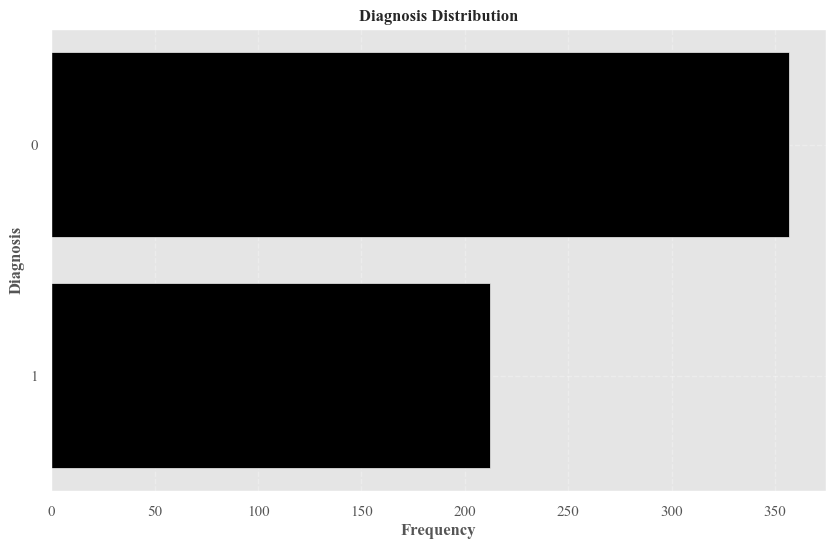

In [11]:
from matplotlib import rcParams

rcParams['font.family'] = 'Times New Roman'

fig, ax = plt.subplots(figsize = (10, 6))
sns.countplot(y = 'diagnosis', data = df, color = 'black', ax = ax)
ax.set_title('Diagnosis Distribution', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Frequency', fontweight = 'bold')
ax.set_ylabel('Diagnosis', fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

In [12]:
df.drop('id', axis = 1, inplace = True)
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [13]:
columns = df.drop('diagnosis', axis = 1)
columns.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


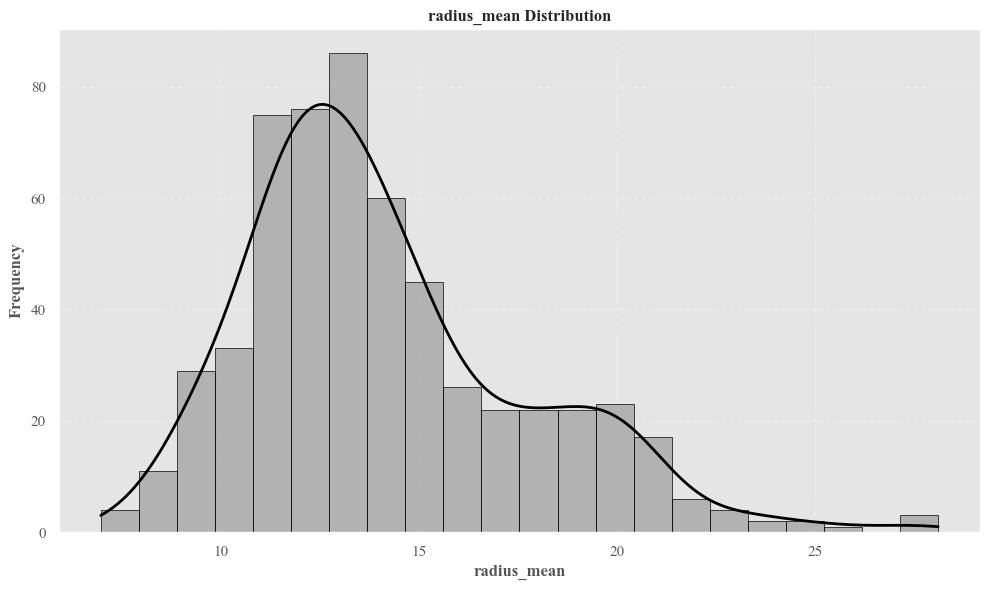

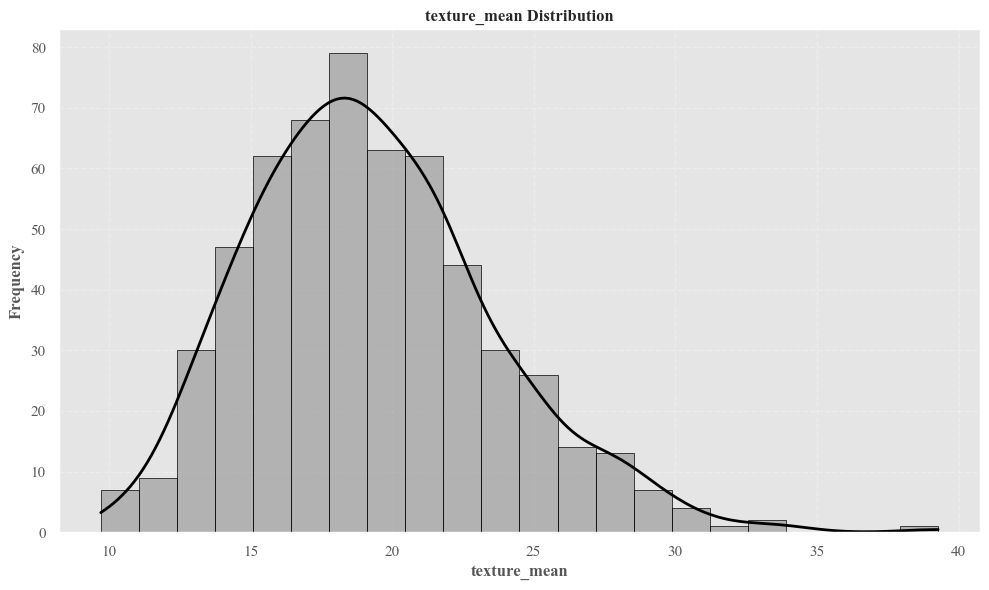

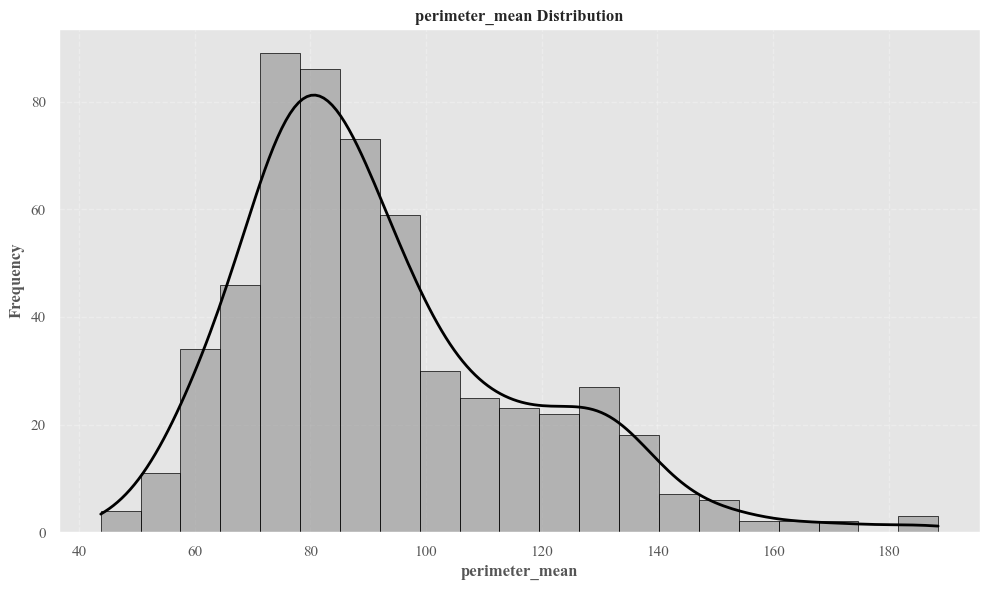

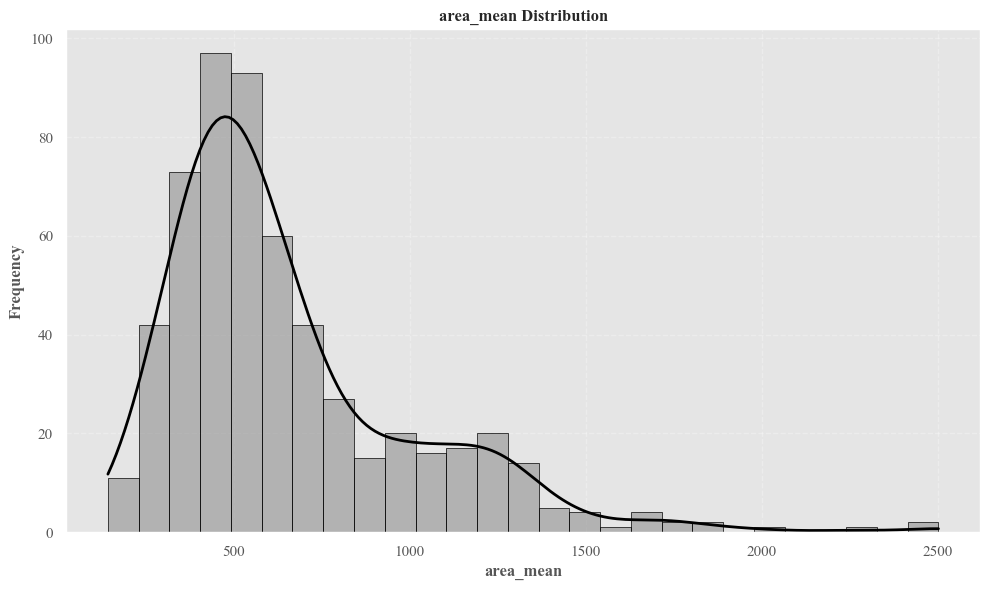

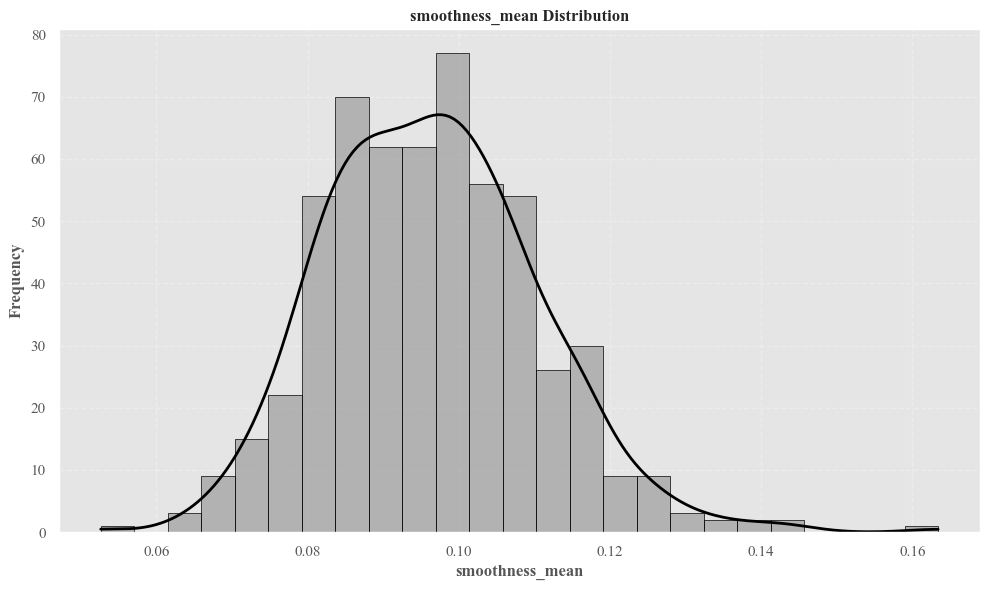

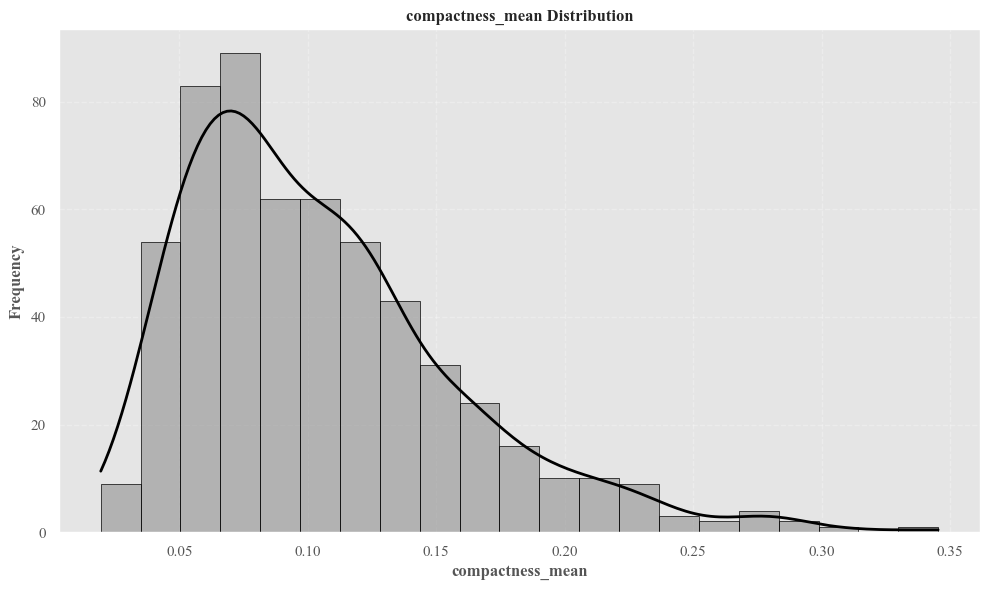

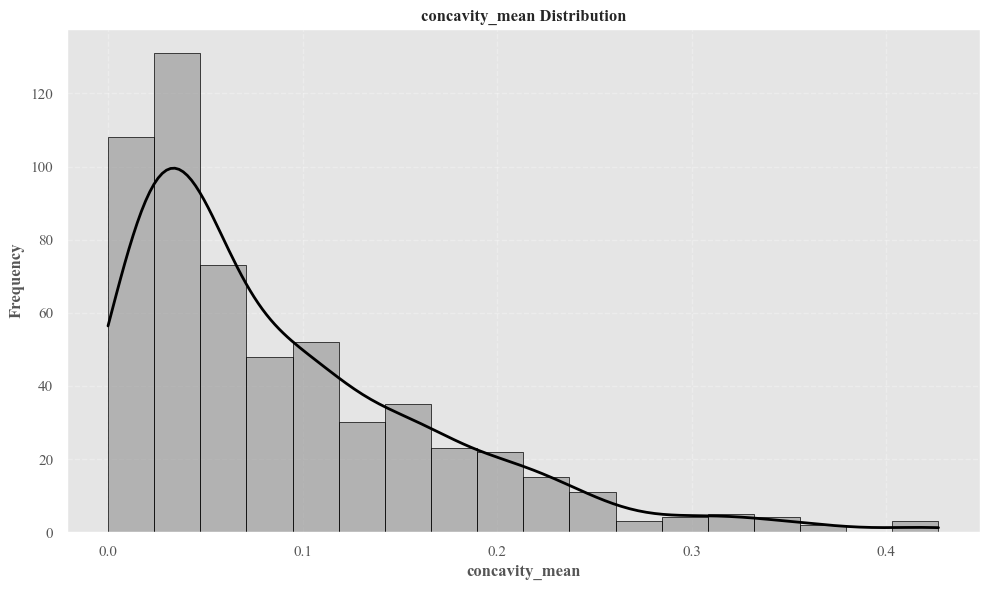

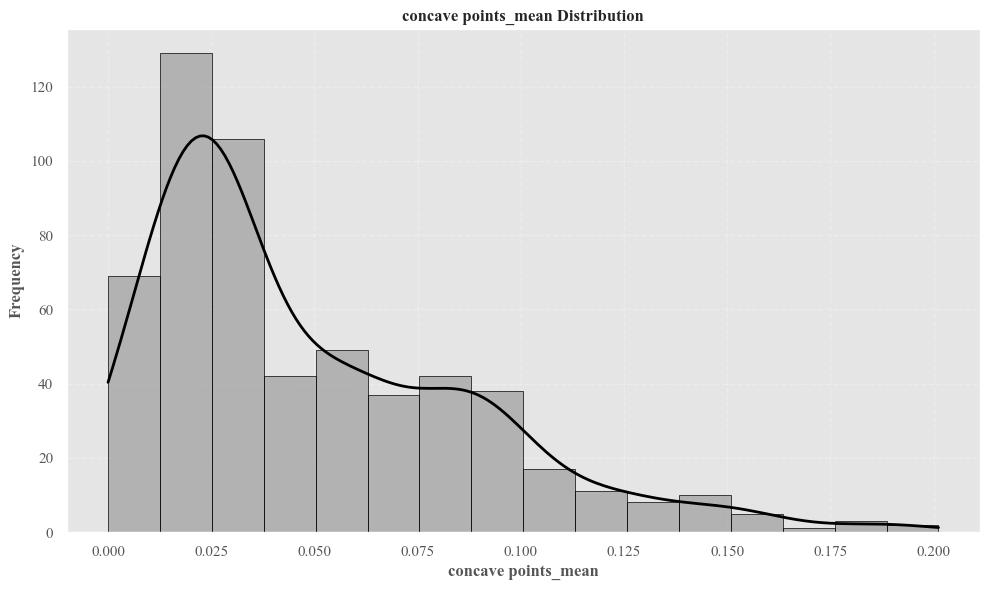

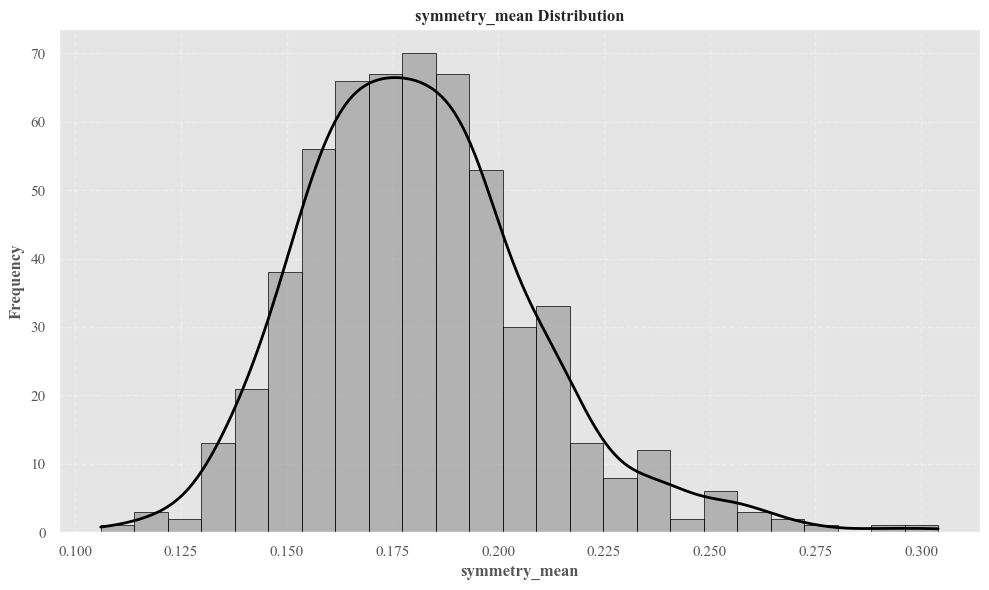

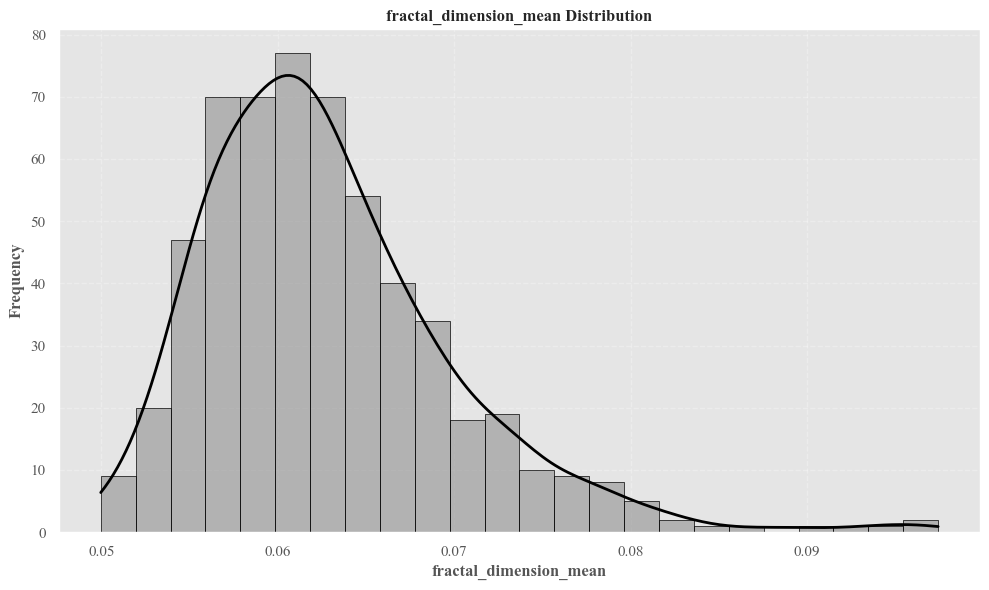

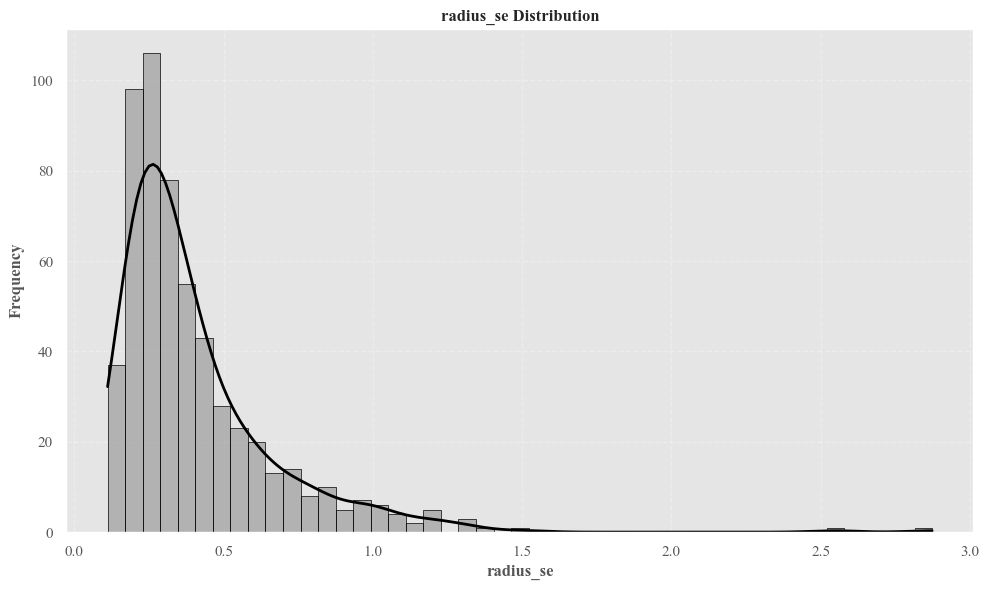

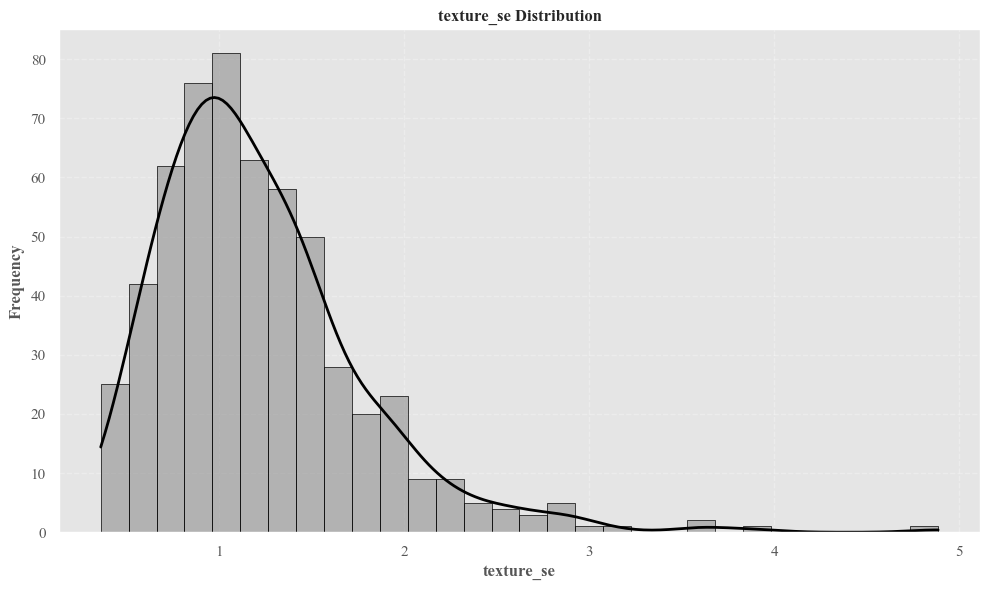

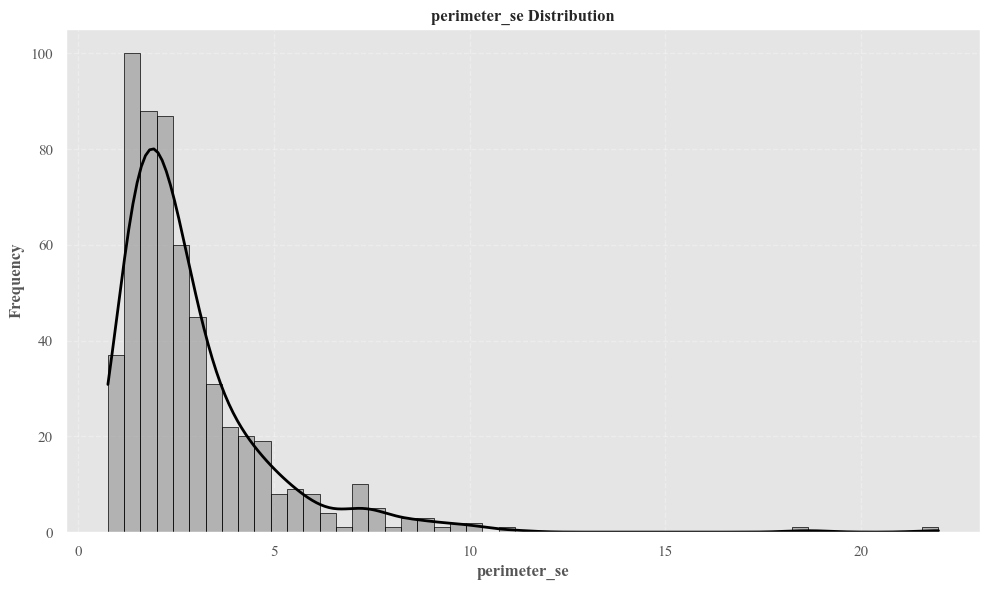

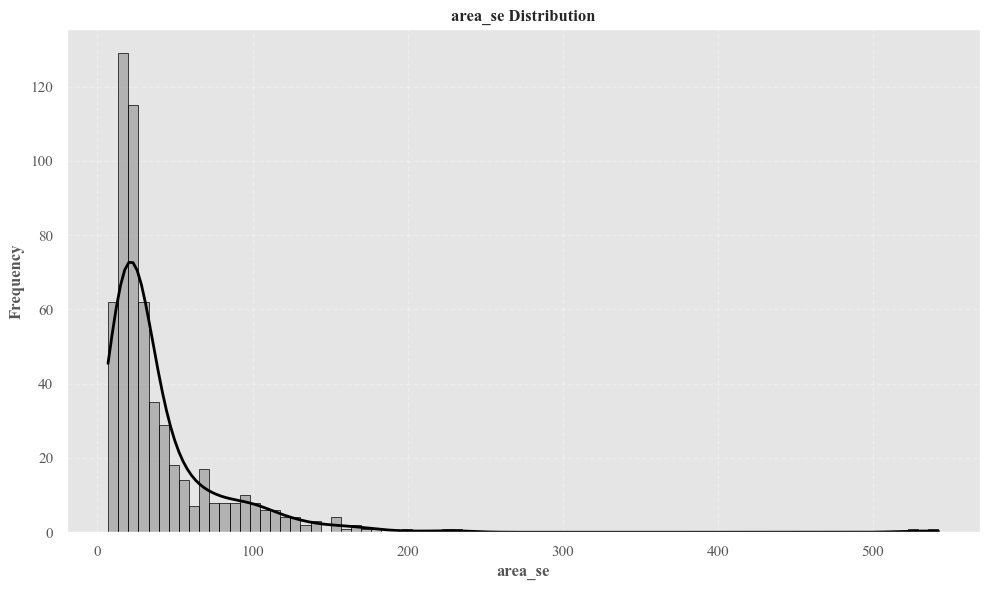

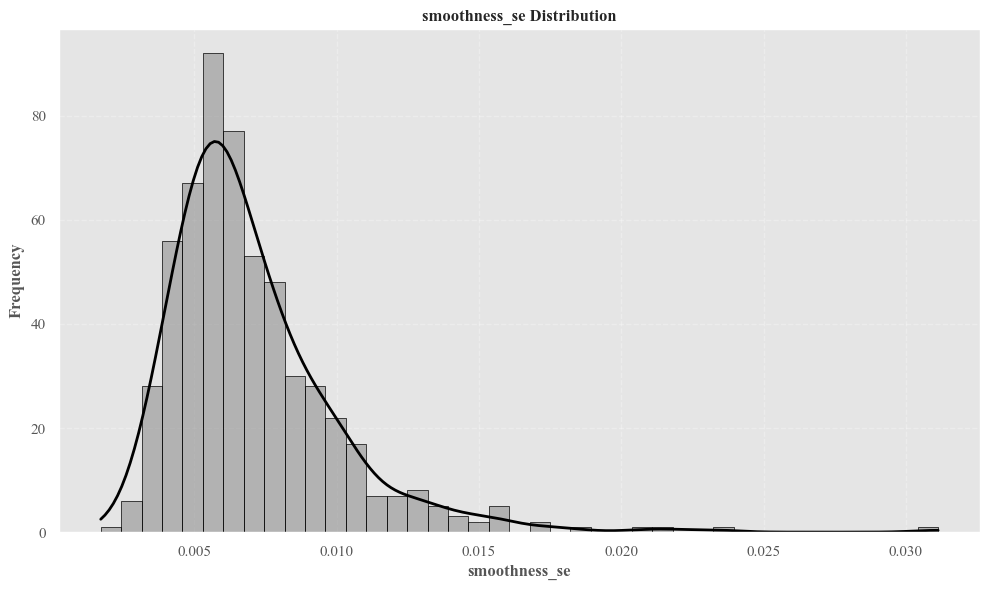

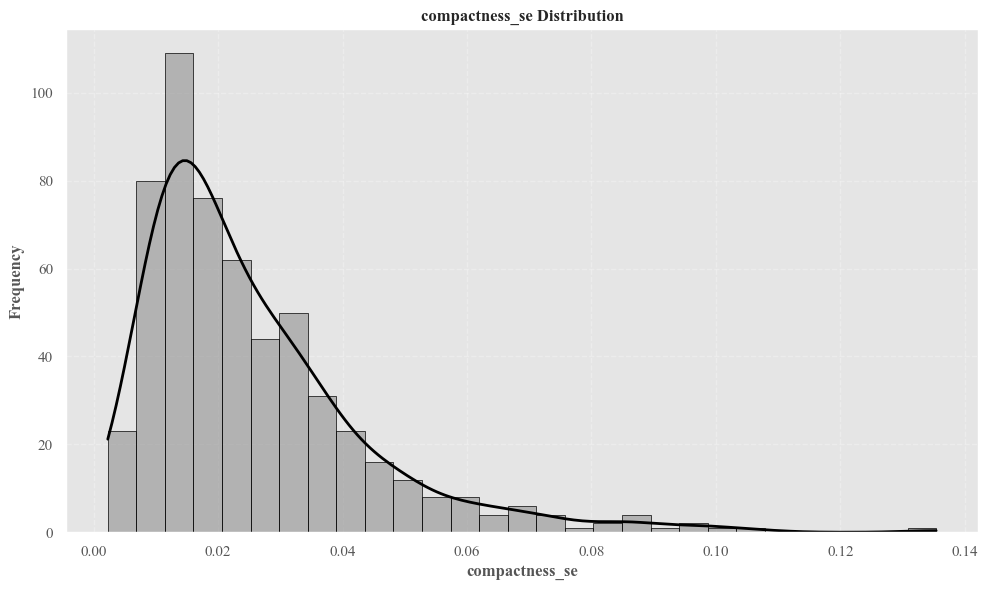

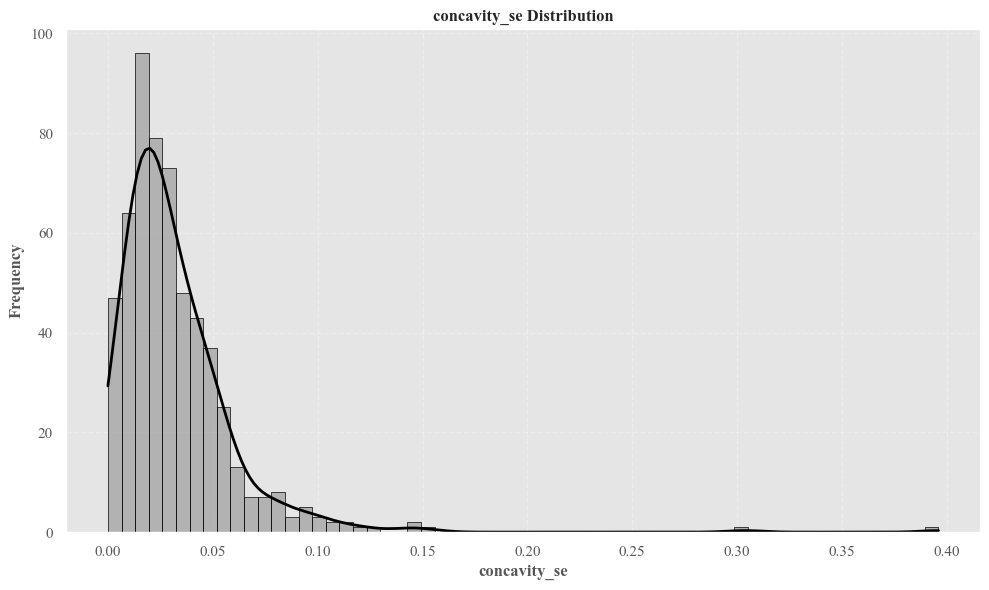

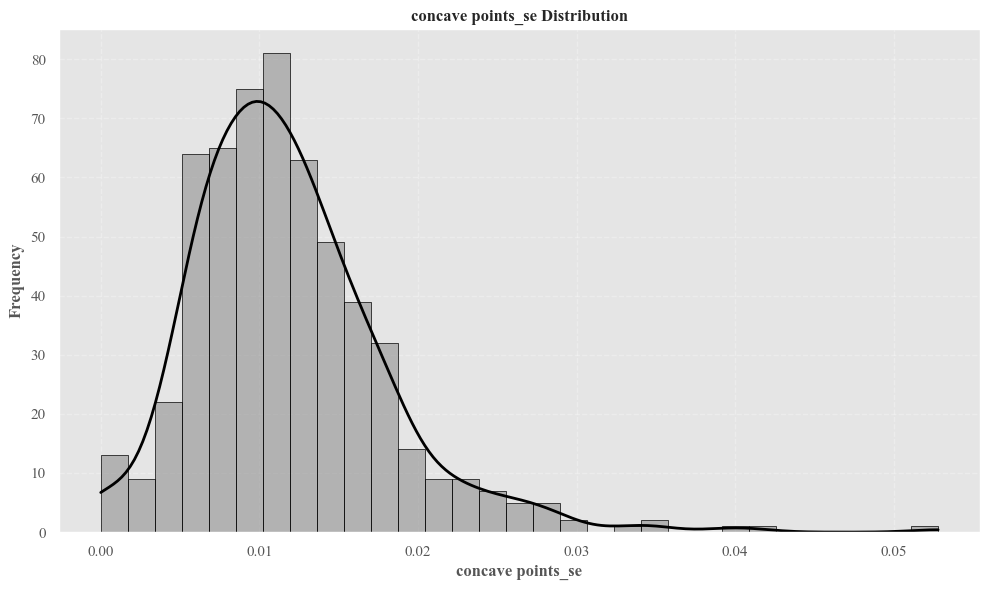

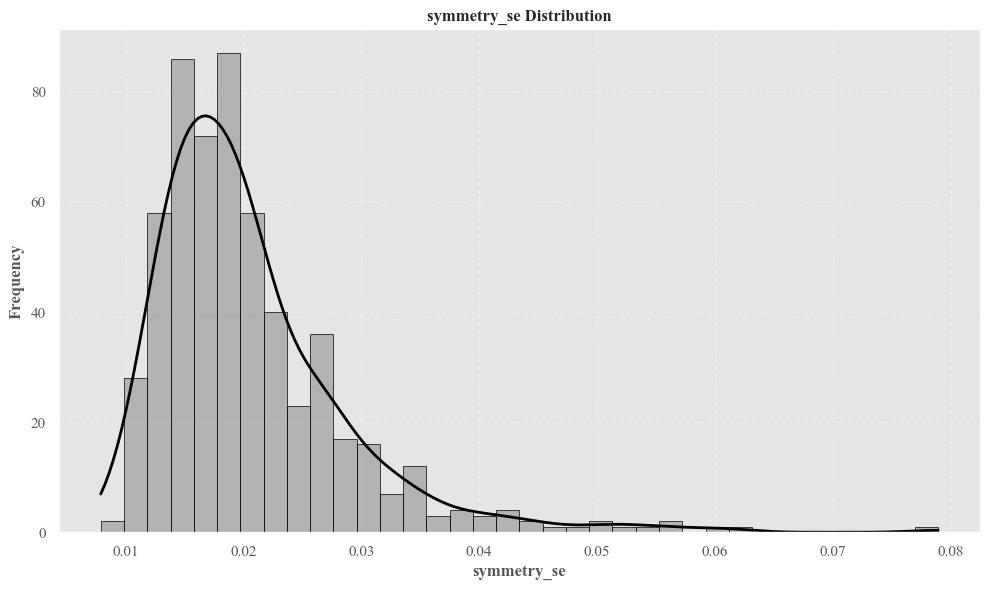

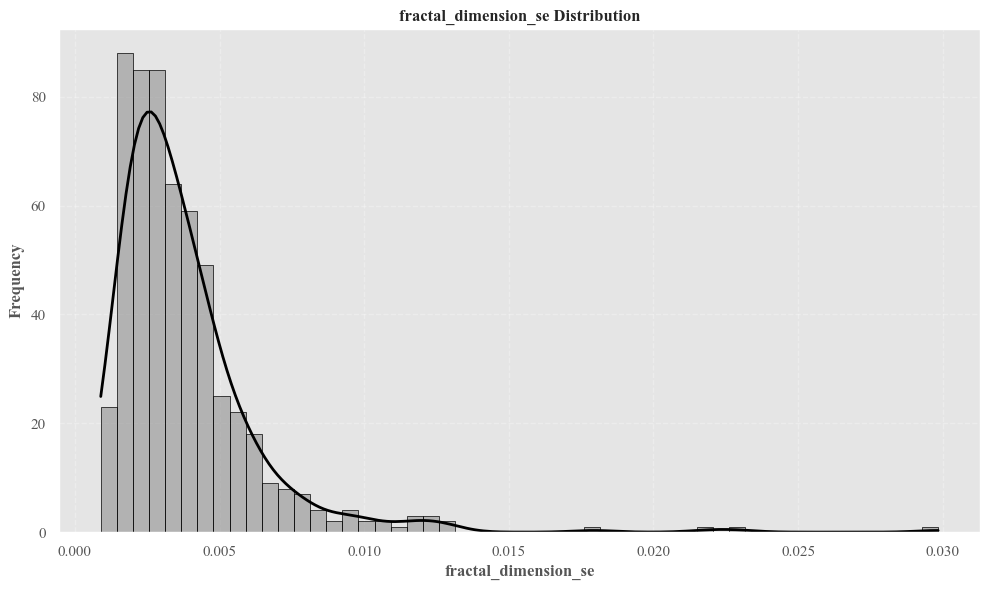

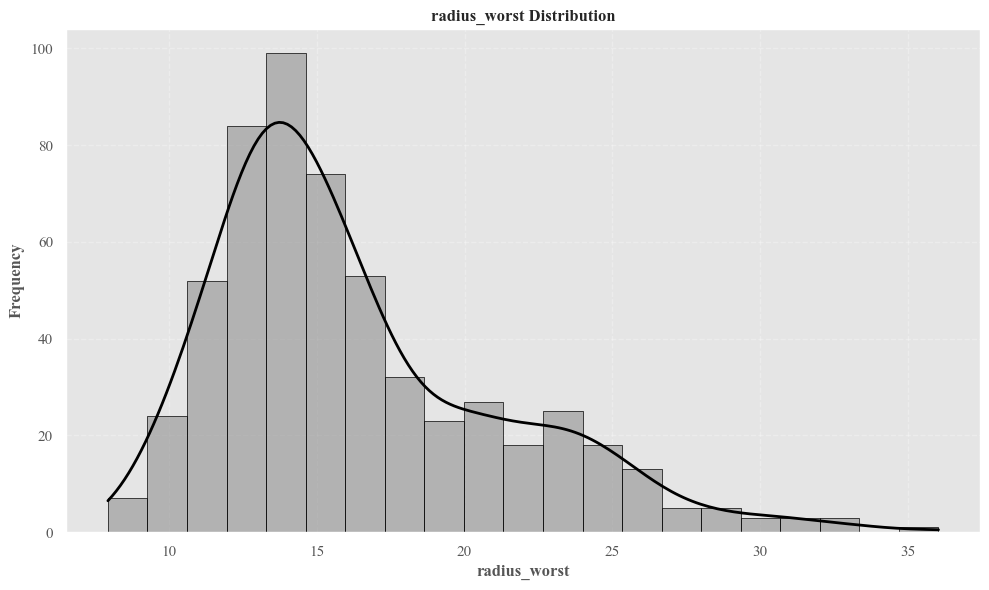

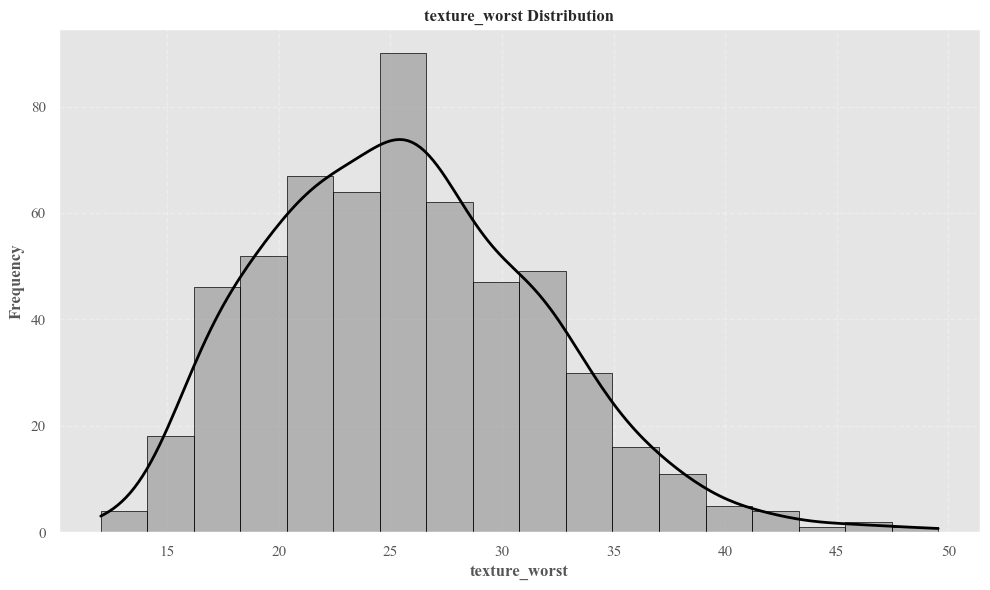

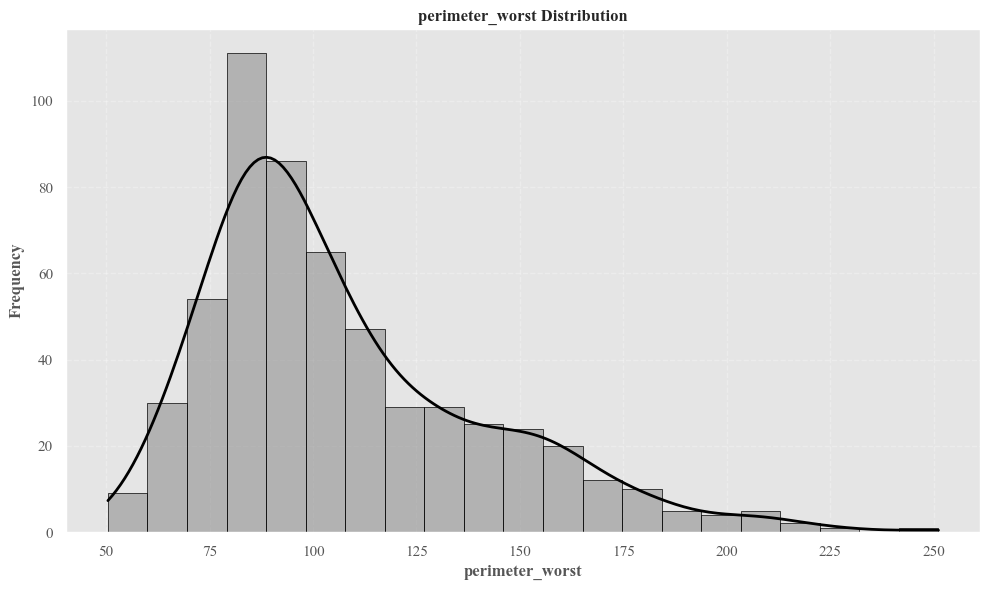

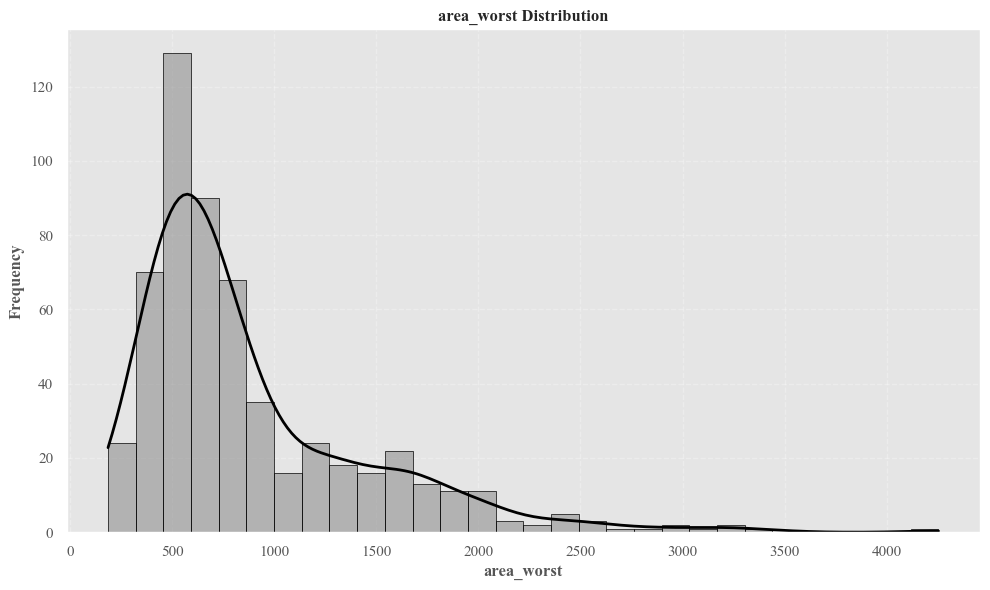

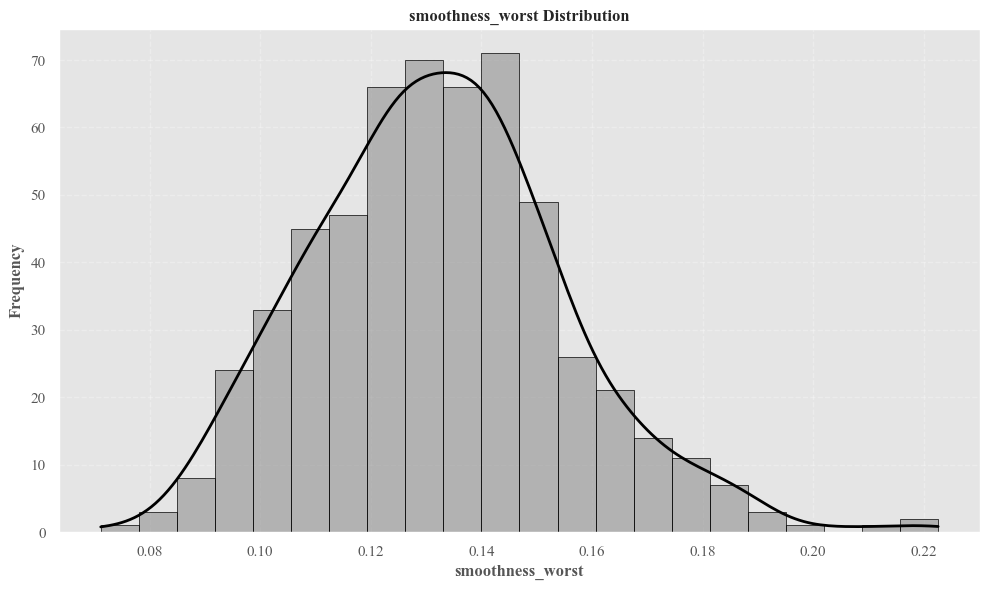

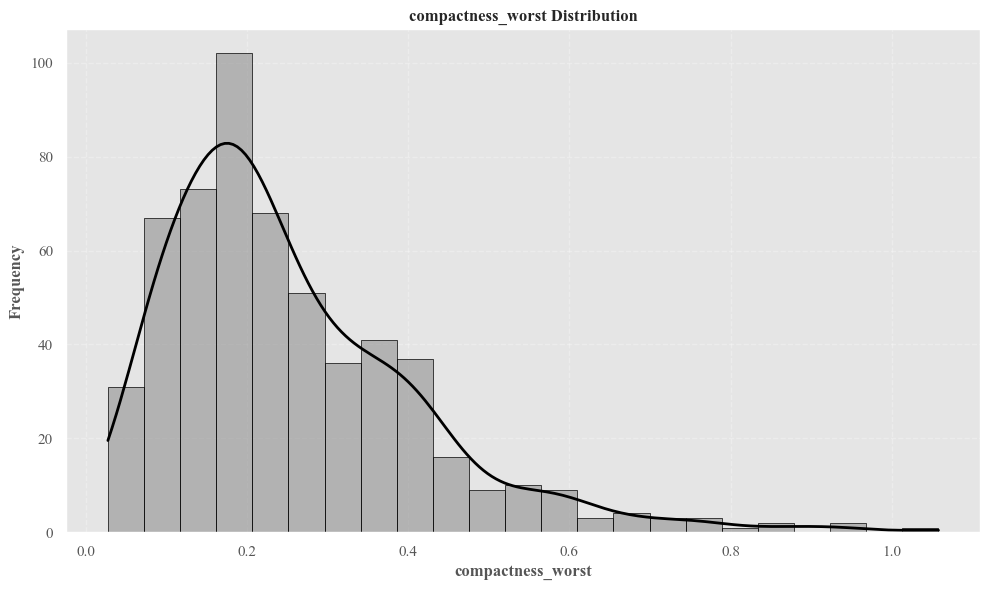

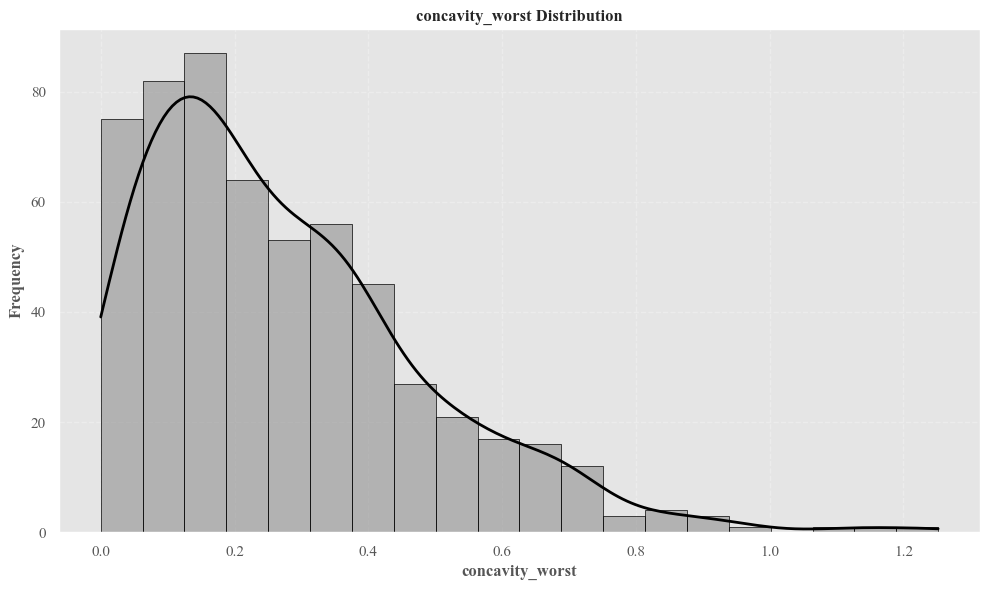

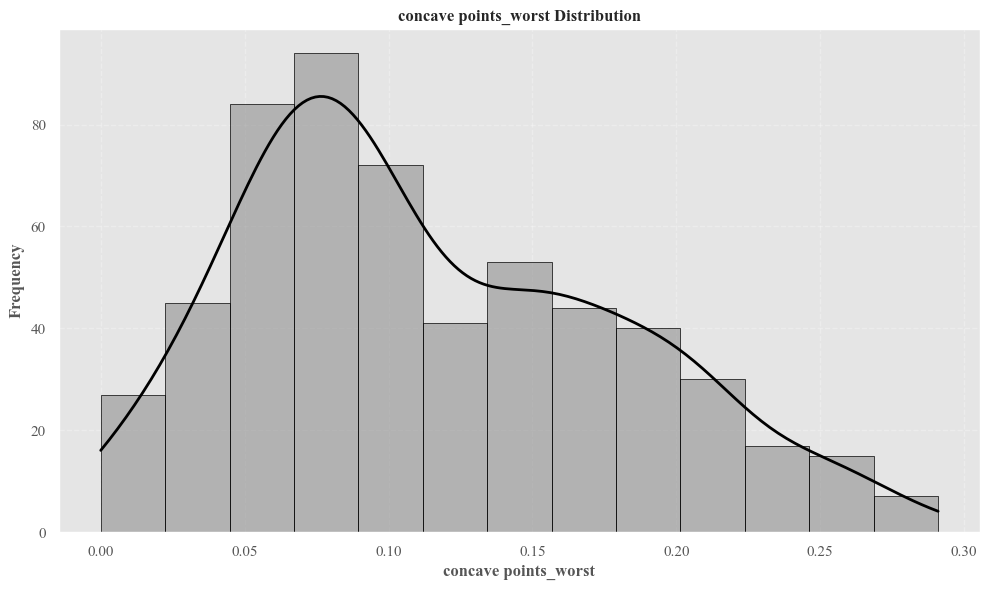

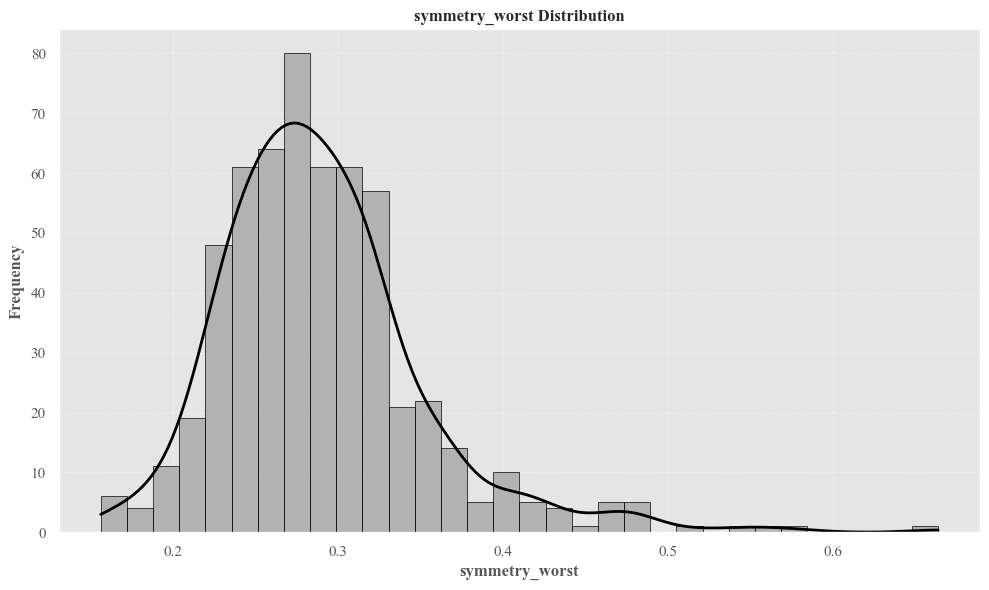

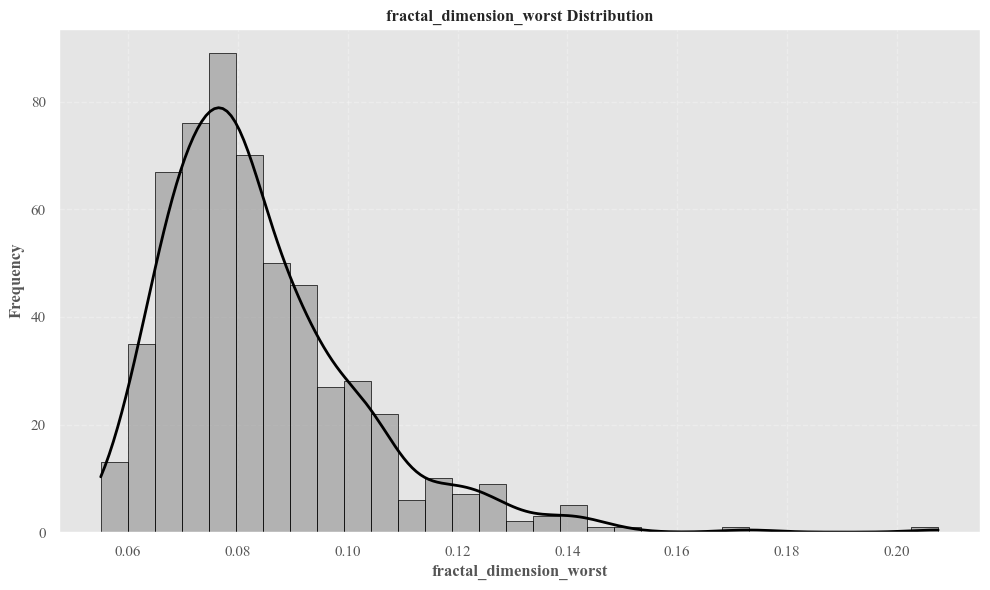

In [14]:
plotnumber = 1

for column in columns:
    if plotnumber <= 30:
        fig, ax = plt.subplots(figsize = (10, 6))
        sns.histplot(df[column], kde = True, color = 'grey', edgecolor = 'black', ax = ax)
        if ax.lines:
            ax.lines[0].set_color('black')
            ax.lines[0].set_linewidth(2)
        ax.set_title(f'{column} Distribution', fontweight = 'bold', fontsize = 12)
        ax.set_xlabel(column, fontweight = 'bold')
        ax.set_ylabel('Frequency', fontweight = 'bold')
        ax.grid(True, linestyle = '--', alpha = 0.3)
        plt.tight_layout()
        plt.show()

    plotnumber += 1

In [15]:
df.corr()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
diagnosis,1.000000,0.730029,0.415185,0.742636,0.708984,0.358560,0.596534,0.696360,0.776614,0.330499,-0.012838,0.567134,-0.008303,0.556141,0.548236,-0.067016,0.292999,0.253730,0.408042,-0.006522,0.077972,0.776454,0.456903,0.782914,0.733825,0.421465,0.590998,0.659610,0.793566,0.416294,0.323872
radius_mean,0.730029,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,-0.311631,0.679090,-0.097317,0.674172,0.735864,-0.222600,0.206000,0.194204,0.376169,-0.104321,-0.042641,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
texture_mean,0.415185,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437,0.275869,0.386358,0.281673,0.259845,0.006614,0.191975,0.143293,0.163851,0.009127,0.054458,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
perimeter_mean,0.742636,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,-0.261477,0.691765,-0.086761,0.693135,0.744983,-0.202694,0.250744,0.228082,0.407217,-0.081629,-0.005523,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
area_mean,0.708984,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,-0.283110,0.732562,-0.066280,0.726628,0.800086,-0.166777,0.212583,0.207660,0.372320,-0.072497,-0.019887,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
smoothness_mean,0.358560,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,0.301467,0.068406,0.296092,0.246552,0.332375,0.318943,0.248396,0.380676,0.200774,0.283607,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
compactness_mean,0.596534,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,0.565369,0.497473,0.046205,0.548905,0.455653,0.135299,0.738722,0.570517,0.642262,0.229977,0.507318,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
concavity_mean,0.696360,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,0.336783,0.631925,0.076218,0.660391,0.617427,0.098564,0.670279,0.691270,0.683260,0.178009,0.449301,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
concave points_mean,0.776614,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,0.166917,0.698050,0.021480,0.710650,0.690299,0.027653,0.490424,0.439167,0.615634,0.095351,0.257584,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661
symmetry_mean,0.330499,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,0.479921,0.303379,0.128053,0.313893,0.223970,0.187321,0.421659,0.342627,0.393298,0.449137,0.331786,0.185728,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413


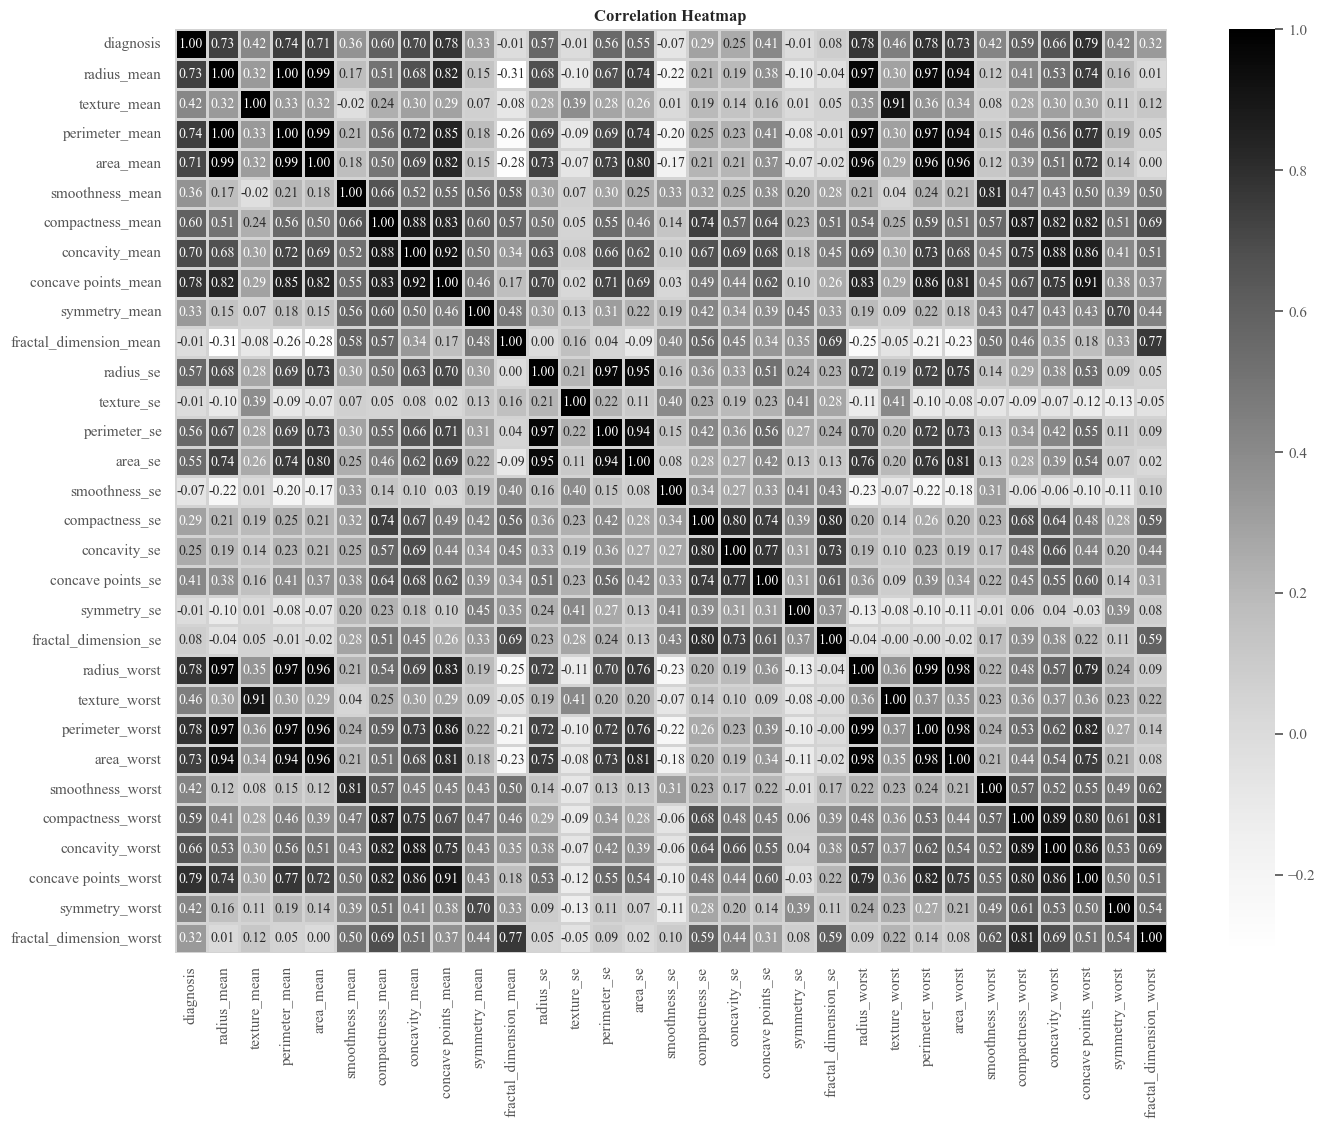

In [16]:
fig, ax = plt.subplots(figsize = (16, 12))
sns.heatmap(df.corr(numeric_only = True), annot = True, cmap = 'Greys',
            fmt = '.2f', linewidth = 2, linecolor = 'lightgray', ax = ax)
ax.set_title('Correlation Heatmap', fontweight = 'bold', fontsize = 12)
ax.grid(False)

plt.show()

In [17]:
df.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [18]:
def violinplot(column):
    fig, ax = plt.subplots(figsize = (10, 6))
    sns.violinplot(x = 'diagnosis', y = column, data = df, color = 'grey', ax = ax)
    sns.boxplot(x = 'diagnosis', y = column, data = df, width = 0.15, color = 'black', ax = ax)
    ax.set_title(f'{column} Distribution by Diagnosis', fontweight = 'bold', fontsize = 12)
    ax.set_xlabel('Diagnosis', fontweight = 'bold')
    ax.set_ylabel(column, fontweight = 'bold')
    ax.grid(True, linestyle = '--', alpha = 0.3)
    plt.tight_layout()
    plt.show()

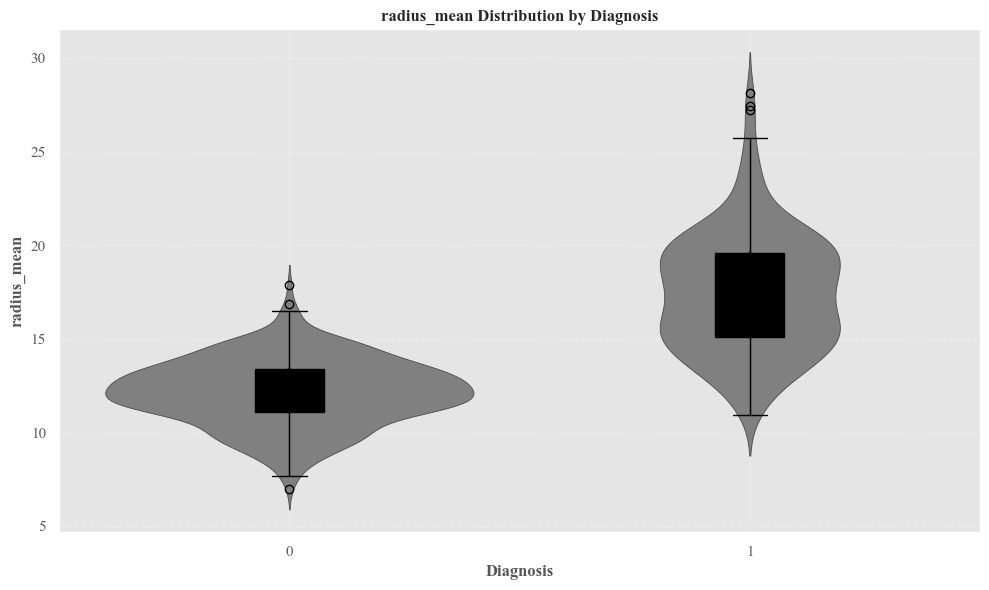

In [19]:
violinplot('radius_mean')

In [20]:
def kde(column):
    fig, ax = plt.subplots(figsize = (10, 6))
    sns.kdeplot(data = df, x = column, hue = 'diagnosis', fill = True, palette = ['grey', 'black'], ax = ax)
    ax.set_title(f'{column} Density Distribution by Diagnosis', fontweight = 'bold', fontsize = 12)
    ax.set_xlabel(column, fontweight = 'bold')
    ax.set_ylabel('Diagnosis', fontweight = 'bold')
    ax.grid(True, linestyle = '--', alpha = 0.3)
    plt.tight_layout()
    plt.show()

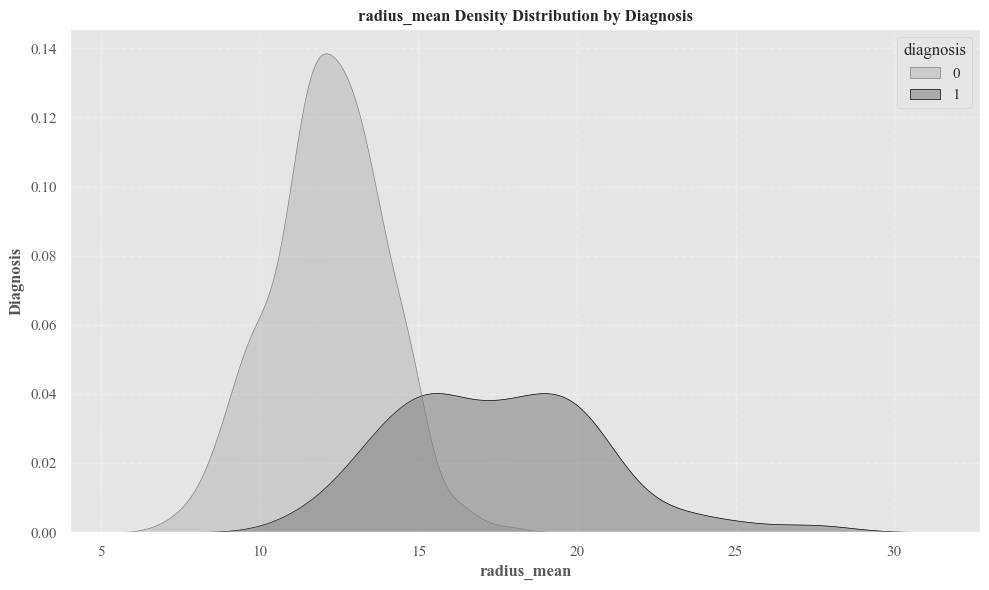

In [21]:
kde('radius_mean')

In [22]:
def scatterplot(column1, column2):
    fig, ax = plt.subplots(figsize = (10, 6))
    sns.scatterplot(x = column1, y = column2, hue = 'diagnosis', data = df, palette = ['grey', 'black'], ax = ax)
    ax.set_title(f'{column1} v. {column2} by Diagnosis', fontweight = 'bold', fontsize = 12)
    ax.set_xlabel(column1, fontweight = 'bold')
    ax.set_ylabel(column2, fontweight = 'bold')
    ax.grid(True, linestyle = '--', alpha = 0.3)
    plt.tight_layout()
    plt.show()

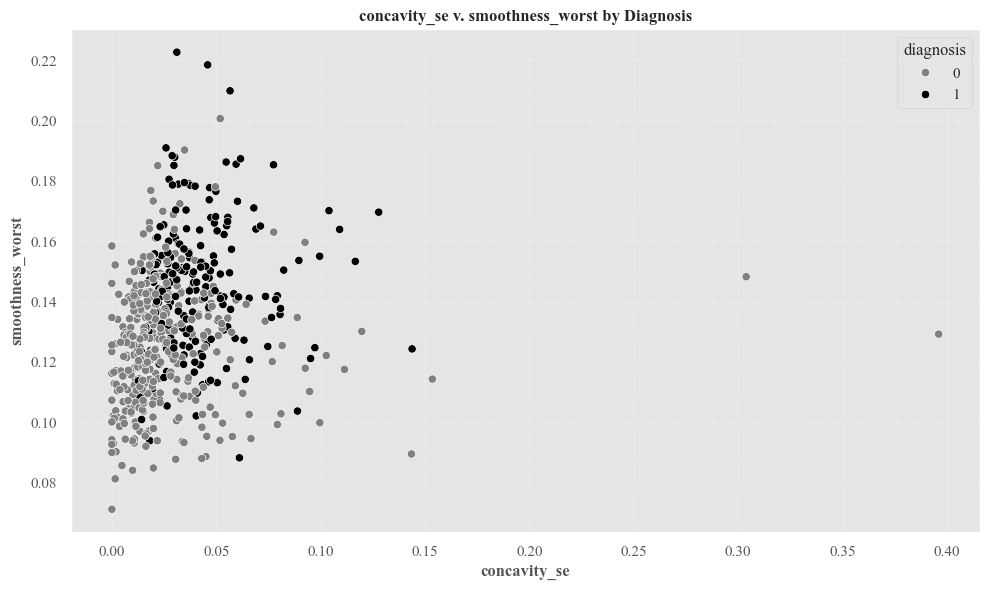

In [23]:
scatterplot('concavity_se', 'smoothness_worst')

In [24]:
outliers_overview = {}

for column in columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    outliers_overview[column] = len(outliers)

outliers_overview

{'radius_mean': 14,
 'texture_mean': 7,
 'perimeter_mean': 13,
 'area_mean': 25,
 'smoothness_mean': 6,
 'compactness_mean': 16,
 'concavity_mean': 18,
 'concave points_mean': 10,
 'symmetry_mean': 15,
 'fractal_dimension_mean': 15,
 'radius_se': 38,
 'texture_se': 20,
 'perimeter_se': 38,
 'area_se': 65,
 'smoothness_se': 30,
 'compactness_se': 28,
 'concavity_se': 22,
 'concave points_se': 19,
 'symmetry_se': 27,
 'fractal_dimension_se': 28,
 'radius_worst': 17,
 'texture_worst': 5,
 'perimeter_worst': 15,
 'area_worst': 35,
 'smoothness_worst': 7,
 'compactness_worst': 16,
 'concavity_worst': 12,
 'concave points_worst': 0,
 'symmetry_worst': 23,
 'fractal_dimension_worst': 24}

In [25]:
df.shape

(569, 31)

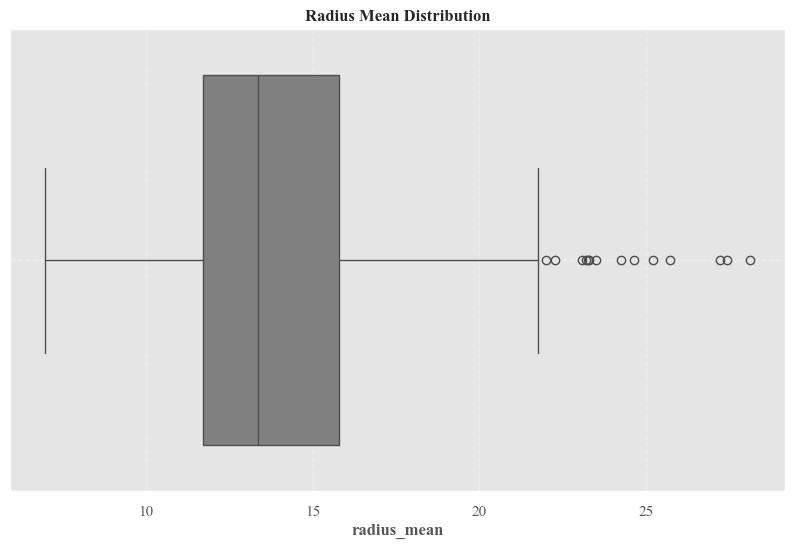

In [26]:
fig, ax = plt.subplots(figsize = (10, 6))
sns.boxplot(x = df['radius_mean'], color = 'grey', ax = ax)
ax.set_title('Radius Mean Distribution', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('radius_mean', fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

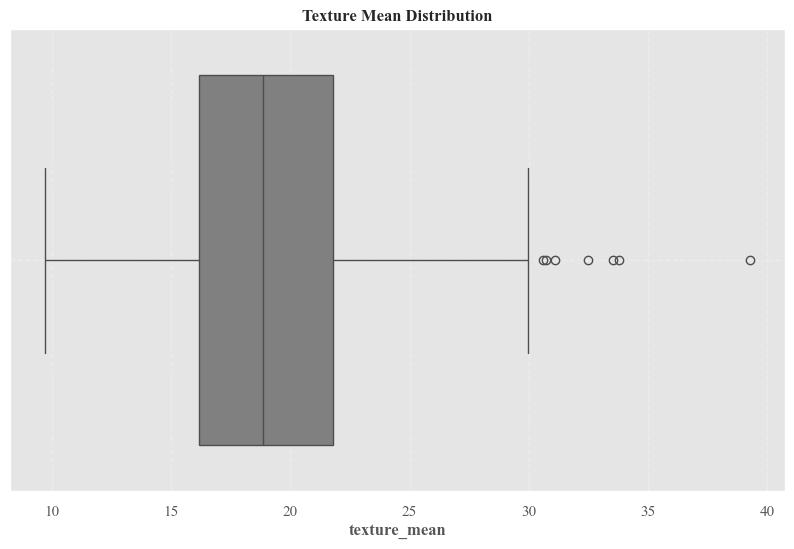

In [27]:
fig, ax = plt.subplots(figsize = (10, 6))
sns.boxplot(x = df['texture_mean'], color = 'grey', ax = ax)
ax.set_title('Texture Mean Distribution', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('texture_mean', fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

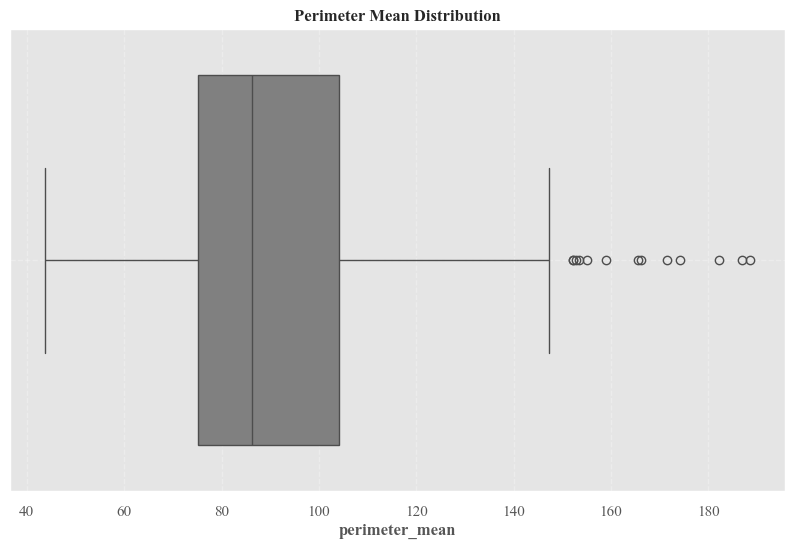

In [28]:
fig, ax = plt.subplots(figsize = (10, 6))
sns.boxplot(x = df['perimeter_mean'], color = 'grey', ax = ax)
ax.set_title('Perimeter Mean Distribution', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('perimeter_mean', fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

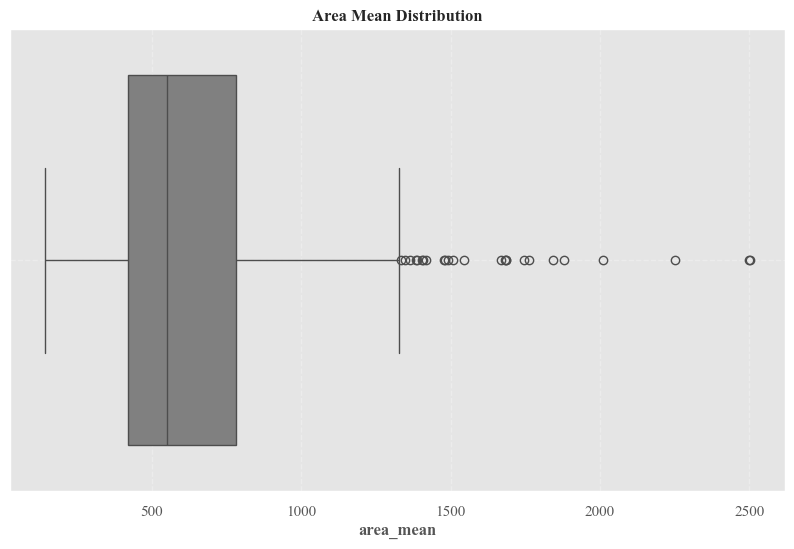

In [29]:
fig, ax = plt.subplots(figsize = (10, 6))
sns.boxplot(x = df['area_mean'], color = 'grey', ax = ax)
ax.set_title('Area Mean Distribution', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('area_mean', fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

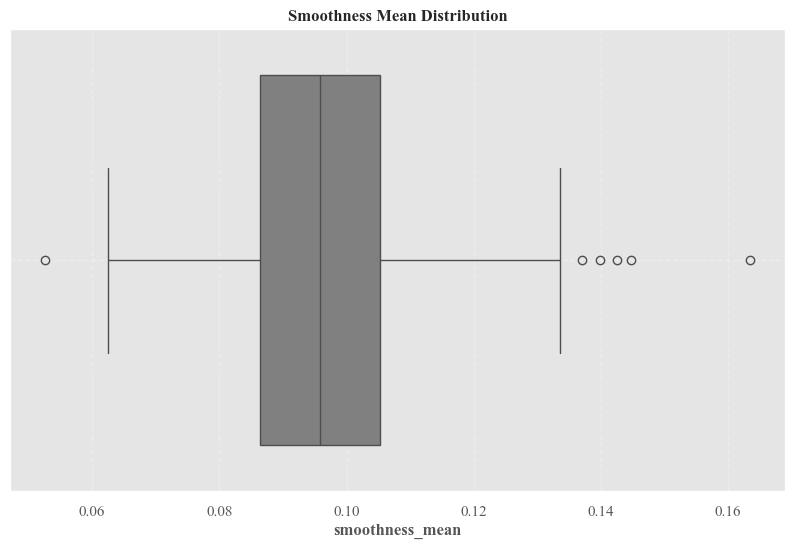

In [30]:
fig, ax = plt.subplots(figsize = (10, 6))
sns.boxplot(x = df['smoothness_mean'], color = 'grey', ax = ax)
ax.set_title('Smoothness Mean Distribution', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('smoothness_mean', fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

In [31]:
df.describe().loc[['min', 'max']]

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
min,0.0,6.981,9.71,43.79,143.5,0.05263,0.01938,0.0000,0.0000,0.106,0.04996,0.1115,0.3602,0.757,6.802,0.001713,0.002252,0.000,0.00000,0.007882,0.000895,7.93,12.02,50.41,185.2,0.07117,0.02729,0.000,0.000,0.1565,0.05504
max,1.0,28.110,39.28,188.50,2501.0,0.16340,0.34540,0.4268,0.2012,0.304,0.09744,2.8730,4.8850,21.980,542.200,0.031130,0.135400,0.396,0.05279,0.078950,0.029840,36.04,49.54,251.20,4254.0,0.22260,1.05800,1.252,0.291,0.6638,0.20750


In [32]:
for column in columns:
    lower_percentile = df[column].quantile(0.025)
    upper_percentile = df[column].quantile(0.975)
    df[column] = df[column].clip(lower = lower_percentile, upper = upper_percentile)

In [33]:
outliers_overview = {}

for column in columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    outliers_overview[column] = len(outliers)

outliers_overview

{'radius_mean': 0,
 'texture_mean': 0,
 'perimeter_mean': 0,
 'area_mean': 25,
 'smoothness_mean': 0,
 'compactness_mean': 16,
 'concavity_mean': 18,
 'concave points_mean': 0,
 'symmetry_mean': 0,
 'fractal_dimension_mean': 15,
 'radius_se': 38,
 'texture_se': 20,
 'perimeter_se': 38,
 'area_se': 65,
 'smoothness_se': 30,
 'compactness_se': 28,
 'concavity_se': 22,
 'concave points_se': 19,
 'symmetry_se': 27,
 'fractal_dimension_se': 28,
 'radius_worst': 17,
 'texture_worst': 0,
 'perimeter_worst': 15,
 'area_worst': 35,
 'smoothness_worst': 0,
 'compactness_worst': 16,
 'concavity_worst': 0,
 'concave points_worst': 0,
 'symmetry_worst': 23,
 'fractal_dimension_worst': 24}

In [34]:
df.describe().loc[['min', 'max']]

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
min,0.0,8.9004,12.358,57.14,244.1,0.072268,0.037202,0.001018,0.002508,0.13592,0.052700,0.14236,0.48074,1.0462,9.6184,0.00334,0.005794,0.000829,0.002390,0.010934,0.001347,9.7554,15.770,63.308,287.56,0.092968,0.059158,0.003856,0.009491,0.19204,0.060338
max,1.0,21.7420,28.666,146.64,1489.2,0.124700,0.234900,0.300260,0.147340,0.24510,0.079342,1.09360,2.59800,8.0224,139.6200,0.01455,0.074556,0.096820,0.026352,0.041960,0.010328,27.9880,38.492,187.760,2395.20,0.180280,0.658740,0.742000,0.254280,0.45672,0.128220


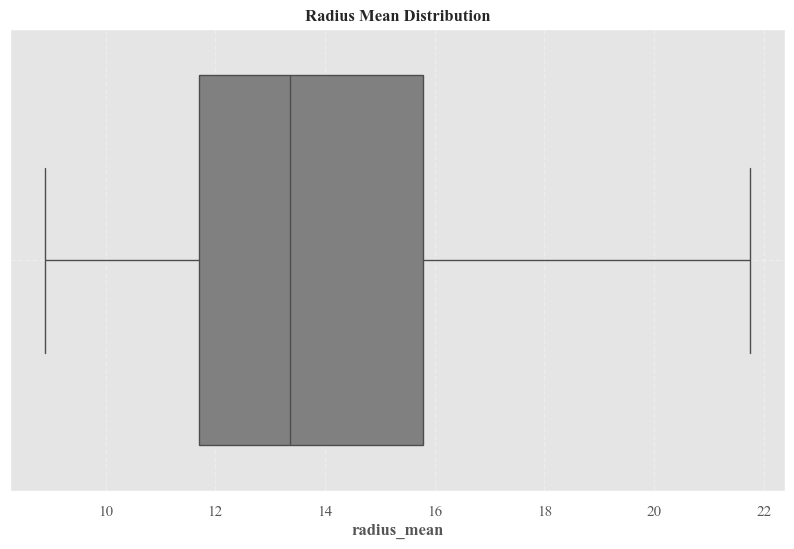

In [35]:
fig, ax = plt.subplots(figsize = (10, 6))
sns.boxplot(x = df['radius_mean'], color = 'grey', ax = ax)
ax.set_title('Radius Mean Distribution', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('radius_mean', fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

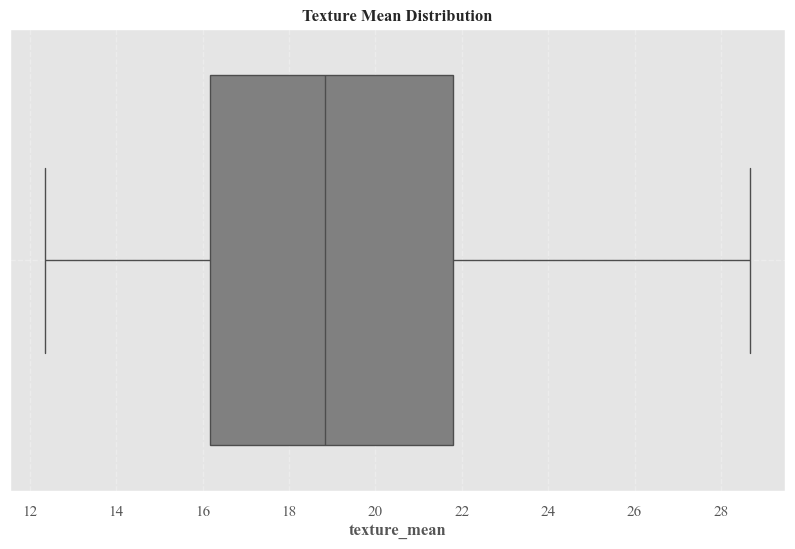

In [36]:
fig, ax = plt.subplots(figsize = (10, 6))
sns.boxplot(x = df['texture_mean'], color = 'grey', ax = ax)
ax.set_title('Texture Mean Distribution', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('texture_mean', fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

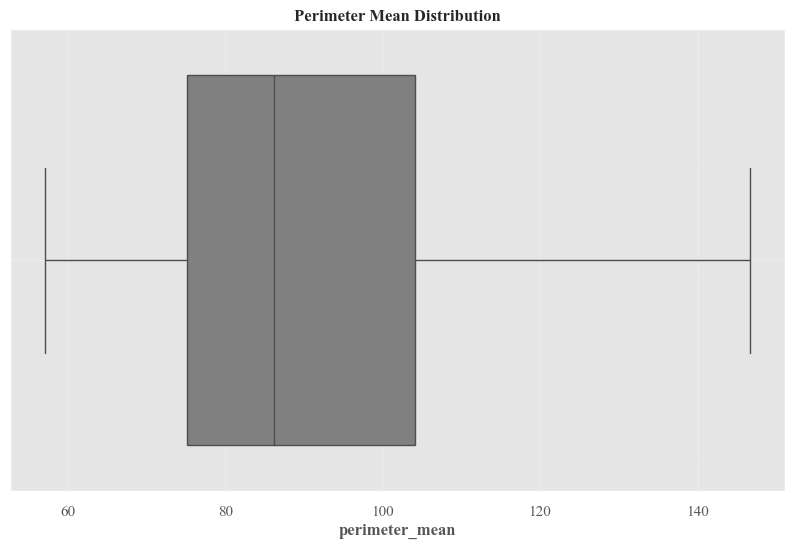

In [37]:
fig, ax = plt.subplots(figsize = (10, 6))
sns.boxplot(x = df['perimeter_mean'], color = 'grey', ax = ax)
ax.set_title('Perimeter Mean Distribution', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('perimeter_mean', fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

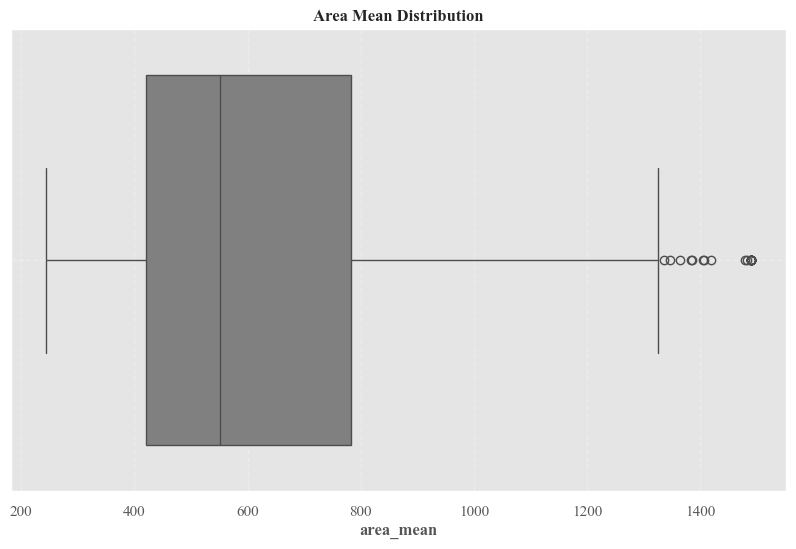

In [38]:
fig, ax = plt.subplots(figsize = (10, 6))
sns.boxplot(x = df['area_mean'], color = 'grey', ax = ax)
ax.set_title('Area Mean Distribution', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('area_mean', fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

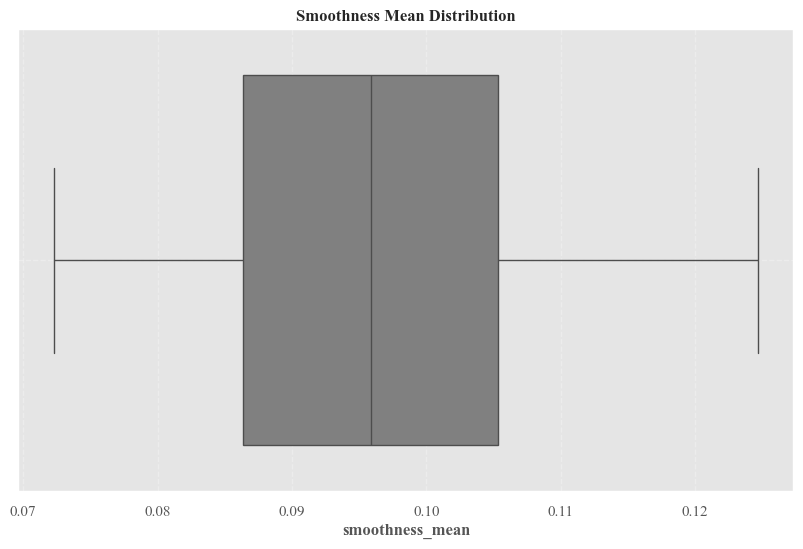

In [39]:
fig, ax = plt.subplots(figsize = (10, 6))
sns.boxplot(x = df['smoothness_mean'], color = 'grey', ax = ax)
ax.set_title('Smoothness Mean Distribution', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('smoothness_mean', fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

In [40]:
X = df.drop('diagnosis', axis = 1)
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0, stratify = y)

In [41]:
X

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.9900,12.358,122.80,1001.0,0.118400,0.23490,0.300100,0.147100,0.2419,0.078710,1.0936,0.9053,8.0224,139.62,0.006399,0.049040,0.053730,0.01587,0.03003,0.006193,25.3800,17.330,184.600,2019.00,0.162200,0.65874,0.711900,0.254280,0.45672,0.11890
1,20.5700,17.770,132.90,1326.0,0.084740,0.07864,0.086900,0.070170,0.1812,0.056670,0.5435,0.7339,3.3980,74.08,0.005225,0.013080,0.018600,0.01340,0.01389,0.003532,24.9900,23.410,158.800,1956.00,0.123800,0.18660,0.241600,0.186000,0.27500,0.08902
2,19.6900,21.250,130.00,1203.0,0.109600,0.15990,0.197400,0.127900,0.2069,0.059990,0.7456,0.7869,4.5850,94.03,0.006150,0.040060,0.038320,0.02058,0.02250,0.004571,23.5700,25.530,152.500,1709.00,0.144400,0.42450,0.450400,0.243000,0.36130,0.08758
3,11.4200,20.380,77.58,386.1,0.124700,0.23490,0.241400,0.105200,0.2451,0.079342,0.4956,1.1560,3.4450,27.23,0.009110,0.074556,0.056610,0.01867,0.04196,0.009208,14.9100,26.500,98.870,567.70,0.180280,0.65874,0.686900,0.254280,0.45672,0.12822
4,20.2900,14.340,135.10,1297.0,0.100300,0.13280,0.198000,0.104300,0.1809,0.058830,0.7572,0.7813,5.4380,94.44,0.011490,0.024610,0.056880,0.01885,0.01756,0.005115,22.5400,16.670,152.200,1575.00,0.137400,0.20500,0.400000,0.162500,0.23640,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.5600,22.390,142.00,1479.0,0.111000,0.11590,0.243900,0.138900,0.1726,0.056230,1.0936,1.2560,7.6730,139.62,0.010300,0.028910,0.051980,0.02454,0.01114,0.004239,25.4500,26.400,166.100,2027.00,0.141000,0.21130,0.410700,0.221600,0.20600,0.07115
565,20.1300,28.250,131.20,1261.0,0.097800,0.10340,0.144000,0.097910,0.1752,0.055330,0.7655,2.4630,5.2030,99.04,0.005769,0.024230,0.039500,0.01678,0.01898,0.002498,23.6900,38.250,155.000,1731.00,0.116600,0.19220,0.321500,0.162800,0.25720,0.06637
566,16.6000,28.080,108.30,858.1,0.084550,0.10230,0.092510,0.053020,0.1590,0.056480,0.4564,1.0750,3.4250,48.55,0.005903,0.037310,0.047300,0.01557,0.01318,0.003892,18.9800,34.120,126.700,1124.00,0.113900,0.30940,0.340300,0.141800,0.22180,0.07820
567,20.6000,28.666,140.10,1265.0,0.117800,0.23490,0.300260,0.147340,0.2397,0.070160,0.7260,1.5950,5.7720,86.22,0.006522,0.061580,0.071170,0.01664,0.02324,0.006185,25.7400,38.492,184.600,1821.00,0.165000,0.65874,0.742000,0.254280,0.40870,0.12400


In [42]:
y

0      1
1      1
2      1
3      1
4      1
      ..
564    1
565    1
566    1
567    1
568    0
Name: diagnosis, Length: 569, dtype: int64

In [43]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(455, 30) (114, 30) (455,) (114,)


In [44]:
knn_pipeline = Pipeline([('scaler', StandardScaler()),
                         ('smote', SMOTE(random_state = 42)),
                         ('model', KNeighborsClassifier())])

knn_params = {'model__n_neighbors': [3, 4, 5, 6, 7, 8, 9, 10],
              'model__weights': ['uniform', 'distance'],
              'model__algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'model__leaf_size': [10, 20, 30, 40, 50],
              'model__p': [1, 2, 3]}

knn_grid_search = GridSearchCV(knn_pipeline, param_grid = knn_params, cv = 5, scoring = 'accuracy', n_jobs = -1)
knn_grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('smote', SMOTE(random_state=42)),
                                       ('model', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'model__algorithm': ['auto', 'ball_tree', 'kd_tree',
                                              'brute'],
                         'model__leaf_size': [10, 20, 30, 40, 50],
                         'model__n_neighbors': [3, 4, 5, 6, 7, 8, 9, 10],
                         'model__p': [1, 2, 3],
                         'model__weights': ['uniform', 'distance']},
             scoring='accuracy')

In [45]:
knn_grid_search.best_params_

{'model__algorithm': 'auto',
 'model__leaf_size': 10,
 'model__n_neighbors': 5,
 'model__p': 1,
 'model__weights': 'uniform'}

In [46]:
print(knn_grid_search.best_score_)

0.9780219780219781


In [47]:
knn = knn_grid_search.best_estimator_
y_pred = knn.predict(X_test)
print('K-Nearest Neighbours')
print(f'Training Accuracy: {accuracy_score(y_train, knn.predict(X_train))}')
knn_acc = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {accuracy_score(y_test, y_pred)}')
print(f'Confusion Matrix: {confusion_matrix(y_test, y_pred)}')
print(f'Classification Report: {classification_report(y_test, y_pred)}')

K-Nearest Neighbours
Training Accuracy: 0.9802197802197802
Test Accuracy: 0.9210526315789473
Confusion Matrix: [[65  7]
 [ 2 40]]
Classification Report:               precision    recall  f1-score   support

           0       0.97      0.90      0.94        72
           1       0.85      0.95      0.90        42

    accuracy                           0.92       114
   macro avg       0.91      0.93      0.92       114
weighted avg       0.93      0.92      0.92       114



In [48]:
logreg_pipeline = Pipeline([('scaler', StandardScaler()),
                            ('smote', SMOTE(random_state = 42)),
                            ('model', LogisticRegression())])

logreg_params = {'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
                 'model__solver': ['lbfgs', 'liblinear', 'saga'],
                 'model__class_weight': [None, 'balanced'],
                 'model__max_iter': [100, 500, 1000]}

logreg_grid_search = GridSearchCV(logreg_pipeline, param_grid = logreg_params, cv = 5, scoring = 'accuracy', n_jobs = -1)
logreg_grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('smote', SMOTE(random_state=42)),
                                       ('model', LogisticRegression())]),
             n_jobs=-1,
             param_grid={'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'model__class_weight': [None, 'balanced'],
                         'model__max_iter': [100, 500, 1000],
                         'model__solver': ['lbfgs', 'liblinear', 'saga']},
             scoring='accuracy')

In [49]:
logreg_grid_search.best_params_

{'model__C': 0.1,
 'model__class_weight': None,
 'model__max_iter': 100,
 'model__solver': 'lbfgs'}

In [50]:
print(logreg_grid_search.best_score_)

0.9868131868131869


In [51]:
logreg = logreg_grid_search.best_estimator_
y_pred = logreg.predict(X_test)
print('Logistic Regression')
print(f'Training Accuracy: {accuracy_score(y_train, logreg.predict(X_train))}')
logreg_acc = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {accuracy_score(y_test, y_pred)}')
print(f'Confusion Matrix: {confusion_matrix(y_test, y_pred)}')
print(f'Classification Report: {classification_report(y_test, y_pred)}')

Logistic Regression
Training Accuracy: 0.989010989010989
Test Accuracy: 0.956140350877193
Confusion Matrix: [[69  3]
 [ 2 40]]
Classification Report:               precision    recall  f1-score   support

           0       0.97      0.96      0.97        72
           1       0.93      0.95      0.94        42

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [52]:
svc_pipeline = Pipeline([('scaler', StandardScaler()),
                         ('smote', SMOTE(random_state = 42)),
                         ('model', SVC(probability = True))])

svc_params = [{'model__kernel': ['linear'],
               'model__C': [0.01, 0.1, 0.5, 1, 10, 20]},
              {'model__kernel': ['rbf'],
               'model__C': [0.01, 0.1, 0.5, 1, 10, 20],
               'model__gamma': [0.0001, 0.001, 0.01, 0.1]},
              {'model__kernel': ['poly'],
               'model__C': [0.01, 0.1, 0.5, 1, 10, 20],
               'model__degree': [2, 3, 4]},
              {'model__kernel': ['sigmoid'],
               'model__C': [0.01, 0.1, 0.5, 1, 10, 20],
               'model__gamma': [0.0001, 0.001, 0.01, 0.1]}]
     
svc_grid_search = GridSearchCV(svc_pipeline, param_grid = svc_params, cv = 5, scoring = 'accuracy', n_jobs = -1)
svc_grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('smote', SMOTE(random_state=42)),
                                       ('model', SVC(probability=True))]),
             n_jobs=-1,
             param_grid=[{'model__C': [0.01, 0.1, 0.5, 1, 10, 20],
                          'model__kernel': ['linear']},
                         {'model__C': [0.01, 0.1, 0.5, 1, 10, 20],
                          'model__gamma': [0.0001, 0.001, 0.01, 0.1],
                          'model__kernel': ['rbf']},
                         {'model__C': [0.01, 0.1, 0.5, 1, 10, 20],
                          'model__degree': [2, 3, 4],
                          'model__kernel': ['poly']},
                         {'model__C': [0.01, 0.1, 0.5, 1, 10, 20],
                          'model__gamma': [0.0001, 0.001, 0.01, 0.1],
                          'model__kernel': ['sigmoid']}],
             scoring='accuracy')

In [53]:
svc_grid_search.best_params_

{'model__C': 10, 'model__gamma': 0.01, 'model__kernel': 'rbf'}

In [54]:
print(svc_grid_search.best_score_)

0.989010989010989


In [55]:
svc = svc_grid_search.best_estimator_
y_pred = svc.predict(X_test)
print('Support Vector Machine')
print(f'Training Accuracy: {accuracy_score(y_train, svc.predict(X_train))}')
svc_acc = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {accuracy_score(y_test, y_pred)}')
print(f'Confusion Matrix: {confusion_matrix(y_test, y_pred)}')
print(f'Classification Report: {classification_report(y_test, y_pred)}')

Support Vector Machine
Training Accuracy: 0.9934065934065934
Test Accuracy: 0.9473684210526315
Confusion Matrix: [[68  4]
 [ 2 40]]
Classification Report:               precision    recall  f1-score   support

           0       0.97      0.94      0.96        72
           1       0.91      0.95      0.93        42

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114



In [56]:
dt_pipeline = Pipeline([('scaler', StandardScaler()),
                        ('smote', SMOTE(random_state = 42)),
                        ('model', DecisionTreeClassifier())])

dt_params = {'model__criterion': ['gini', 'entropy'],
             'model__max_depth': randint(3, 10),
             'model__splitter': ['best', 'random'],
             'model__min_samples_leaf': randint(1, 10),
             'model__min_samples_split': randint(2, 10),
             'model__max_features': [None, 'sqrt', 'log2']}

dt_random_search = RandomizedSearchCV(estimator = dt_pipeline, param_distributions = dt_params,
                                      n_iter = 50, scoring = 'accuracy', cv = 5, random_state = 42, n_jobs = -1)
dt_random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('smote', SMOTE(random_state=42)),
                                             ('model',
                                              DecisionTreeClassifier())]),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'model__criterion': ['gini', 'entropy'],
                                        'model__max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000017167A73410>,
                                        'model__max_features': [None, 'sqrt',
                                                                'log2'],
                                        'model__min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000171683E6E40>,
                                        'model__min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000017168360680>,
                                        'model__splitter': ['best', 'random']},
                   random_state=42, scoring='accuracy')

In [57]:
dt_random_search.best_params_

{'model__criterion': 'gini',
 'model__max_depth': 5,
 'model__max_features': 'sqrt',
 'model__min_samples_leaf': 3,
 'model__min_samples_split': 2,
 'model__splitter': 'best'}

In [58]:
print(dt_random_search.best_score_)

0.9428571428571428


In [59]:
dt = dt_random_search.best_estimator_
y_pred = dt.predict(X_test)
print('Decision Tree')
print(f'Training Accuracy: {accuracy_score(y_train, dt.predict(X_train))}')
dt_acc = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {accuracy_score(y_test, y_pred)}')
print(f'Confusion Matrix: {confusion_matrix(y_test, y_pred)}')
print(f'Classification Report: {classification_report(y_test, y_pred)}')

Decision Tree
Training Accuracy: 0.9736263736263736
Test Accuracy: 0.9298245614035088
Confusion Matrix: [[68  4]
 [ 4 38]]
Classification Report:               precision    recall  f1-score   support

           0       0.94      0.94      0.94        72
           1       0.90      0.90      0.90        42

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



In [60]:
rf_pipeline = Pipeline([('scaler', StandardScaler()),
                        ('smote', SMOTE(random_state = 42)),
                        ('model', RandomForestClassifier())])

rf_params = {'model__n_estimators': randint(50, 1000),
             'model__criterion': ['gini', 'entropy', 'log_loss'],
             'model__max_depth': randint(3, 30),
             'model__min_samples_split': randint(2, 10), 
             'model__min_samples_leaf': randint(1, 10),
             'model__max_features': [None, 'sqrt', 'log2'], 
             'model__bootstrap': [True, False],
             'model__class_weight': [None]}

rf_random_search = RandomizedSearchCV(estimator = rf_pipeline, param_distributions = rf_params,
                                      n_iter = 50, scoring = 'accuracy', cv = 5, random_state = 42, n_jobs = -1)
rf_random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('smote', SMOTE(random_state=42)),
                                             ('model',
                                              RandomForestClassifier())]),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'model__bootstrap': [True, False],
                                        'model__class_weight': [None],
                                        'model__criterion': ['gini', 'entropy',
                                                             'log_loss'],
                                        'model__max_depth': <scipy.stats._distn_infrastructu...
                                        'model__min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001716CDB38F0>,
                                        'model__min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001716CD979B0>,
                                        'model__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001716CDB3860>},
                   random_state=42, scoring='accuracy')

In [61]:
rf_random_search.best_params_

{'model__bootstrap': False,
 'model__class_weight': None,
 'model__criterion': 'gini',
 'model__max_depth': 23,
 'model__max_features': 'sqrt',
 'model__min_samples_leaf': 4,
 'model__min_samples_split': 7,
 'model__n_estimators': 380}

In [62]:
print(rf_random_search.best_score_)

0.9692307692307693


In [63]:
rf = rf_random_search.best_estimator_
y_pred = rf.predict(X_test)
print('Random Forest')
print(f'Training Accuracy: {accuracy_score(y_train, rf.predict(X_train))}')
rf_acc = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {accuracy_score(y_test, y_pred)}')
print(f'Confusion Matrix: {confusion_matrix(y_test, y_pred)}')
print(f'Classification Report: {classification_report(y_test, y_pred)}')

Random Forest
Training Accuracy: 0.9934065934065934
Test Accuracy: 0.9298245614035088
Confusion Matrix: [[66  6]
 [ 2 40]]
Classification Report:               precision    recall  f1-score   support

           0       0.97      0.92      0.94        72
           1       0.87      0.95      0.91        42

    accuracy                           0.93       114
   macro avg       0.92      0.93      0.93       114
weighted avg       0.93      0.93      0.93       114



In [64]:
gbc_pipeline = Pipeline([('scaler', StandardScaler()),
                         ('smote', SMOTE(random_state = 42)),
                         ('model', GradientBoostingClassifier())])

gbc_params = {'model__loss': ['log_loss', 'exponential'],
              'model__learning_rate': uniform(0.01, 0.3),
              'model__n_estimators': randint(50, 300),
              'model__criterion': ['friedman_mse', 'squared_error'],
              'model__min_samples_split': randint(2, 10),
              'model__min_samples_leaf': randint(1, 10),
              'model__min_weight_fraction_leaf': uniform(0, 0.5),
              'model__max_depth': randint(1, 5),
              'model__max_features': [None, 'sqrt', 'log2']}

gbc_random_search = RandomizedSearchCV(estimator = gbc_pipeline, param_distributions = gbc_params,
                                       n_iter = 50, scoring = 'accuracy', cv = 5, random_state = 42, n_jobs = -1)
gbc_random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('smote', SMOTE(random_state=42)),
                                             ('model',
                                              GradientBoostingClassifier())]),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'model__criterion': ['friedman_mse',
                                                             'squared_error'],
                                        'model__learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001716D280350>...
                                        'model__min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001716D1EA7E0>,
                                        'model__min_weight_fraction_leaf': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001716D1E96A0>,
                                        'model__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001716D2D3410>},
                   random_state=42, scoring='accuracy')

In [65]:
gbc_random_search.best_params_

{'model__criterion': 'friedman_mse',
 'model__learning_rate': np.float64(0.09869010575131419),
 'model__loss': 'log_loss',
 'model__max_depth': 2,
 'model__max_features': 'sqrt',
 'model__min_samples_leaf': 7,
 'model__min_samples_split': 5,
 'model__min_weight_fraction_leaf': np.float64(0.17814891903848745),
 'model__n_estimators': 239}

In [66]:
print(gbc_random_search.best_score_)

0.9714285714285715


In [67]:
gbc = gbc_random_search.best_estimator_
y_pred = gbc.predict(X_test)
print('Gradient Boosting Classifier')
print(f'Training Accuracy: {accuracy_score(y_train, gbc.predict(X_train))}')
gbc_acc = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {accuracy_score(y_test, y_pred)}')
print(f'Confusion Matrix: {confusion_matrix(y_test, y_pred)}')
print(f'Classification Report: {classification_report(y_test, y_pred)}')

Gradient Boosting Classifier
Training Accuracy: 1.0
Test Accuracy: 0.9473684210526315
Confusion Matrix: [[68  4]
 [ 2 40]]
Classification Report:               precision    recall  f1-score   support

           0       0.97      0.94      0.96        72
           1       0.91      0.95      0.93        42

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114



In [68]:
xgb_pipeline = Pipeline([('scaler', StandardScaler()),
                         ('smote', SMOTE(random_state = 42)),
                         ('model', XGBClassifier(objective = 'binary:logistic', eval_metric = 'logloss', random_state = 42))])

xgb_params = {'model__max_depth': randint(3, 10),
              'model__learning_rate': uniform(0.01, 0.2),
              'model__n_estimators': randint(50, 500),
              'model__subsample': uniform(0.4, 0.6),
              'model__colsample_bytree': uniform(0.4, 0.6),
              'model__min_child_weight': randint(1, 5),
              'model__gamma': uniform(0, 0.5),
              'model__reg_alpha': uniform(0, 0.1),
              'model__reg_lambda': uniform(1, 10),
              'model__tree_method': ['hist']}

xgb_random_search = RandomizedSearchCV(estimator = xgb_pipeline, param_distributions = xgb_params,
                                       n_iter = 50, scoring = 'accuracy', cv = 5, random_state = 42, n_jobs = -1)
xgb_random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('smote', SMOTE(random_state=42)),
                                             ('model',
                                              XGBClassifier(base_score=None,
                                                            booster=None,
                                                            callbacks=None,
                                                            colsample_bylevel=None,
                                                            colsample_bynode=None,
                                                            colsample_bytree=None,
                                                            device=None,
                                                            early_stopping_rounds=None,
                                                            enable_categorical=True,
                                                            eval_metric='logloss',
                                                            feature_types=None,
                                                            f...
                                        'model__reg_alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000017167867410>,
                                        'model__reg_lambda': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000017167865FA0>,
                                        'model__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001716260D2E0>,
                                        'model__tree_method': ['hist']},
                   random_state=42, scoring='accuracy')

In [69]:
xgb_random_search.best_params_

{'model__colsample_bytree': np.float64(0.4830118554506808),
 'model__gamma': np.float64(0.0663727111214849),
 'model__learning_rate': np.float64(0.20390737342283183),
 'model__max_depth': 4,
 'model__min_child_weight': 2,
 'model__n_estimators': 196,
 'model__reg_alpha': np.float64(0.07951861947687038),
 'model__reg_lambda': np.float64(3.708322512620742),
 'model__subsample': np.float64(0.6633828524233817),
 'model__tree_method': 'hist'}

In [70]:
print(xgb_random_search.best_score_)

0.9692307692307691


In [71]:
xgb = xgb_random_search.best_estimator_
y_pred = xgb.predict(X_test)
print('XGBoost Classifier')
print(f'Training Accuracy: {accuracy_score(y_train, xgb.predict(X_train))}')
xgb_acc = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {accuracy_score(y_test, y_pred)}')
print(f'Confusion Matrix: {confusion_matrix(y_test, y_pred)}')
print(f'Classification Report: {classification_report(y_test, y_pred)}')

XGBoost Classifier
Training Accuracy: 0.9978021978021978
Test Accuracy: 0.9473684210526315
Confusion Matrix: [[68  4]
 [ 2 40]]
Classification Report:               precision    recall  f1-score   support

           0       0.97      0.94      0.96        72
           1       0.91      0.95      0.93        42

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114



In [72]:
mlp_pipeline = Pipeline([('scaler', StandardScaler()),
                         ('smote', SMOTE(random_state = 42)),
                         ('model', MLPClassifier())])

mlp_params = {'model__activation': ['logistic', 'tanh', 'relu'],
              'model__solver': ['sgd', 'adam'],
              'model__alpha': loguniform(1e-6, 1e-2),
              'model__learning_rate_init': loguniform(1e-5, 1e-1),
              'model__learning_rate': ['constant', 'adaptive'],
              'model__max_iter': randint(200, 1000),
              'model__hidden_layer_sizes': [(50,), (100,), (100, 50), (128, 64), (256, 128, 64)],
              'model__batch_size': [32, 64, 128],
              'model__early_stopping': [True, False]}

mlp_random_search = RandomizedSearchCV(estimator = mlp_pipeline, param_distributions = mlp_params,
                                       n_iter = 50, cv = 5, scoring = 'accuracy', random_state = 42, n_jobs = -1)

mlp_random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('smote', SMOTE(random_state=42)),
                                             ('model', MLPClassifier())]),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'model__activation': ['logistic',
                                                              'tanh', 'relu'],
                                        'model__alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001716B9C6E10>,
                                        'model__batch_size': [32, 6...
                                                                      (100, 50),
                                                                      (128, 64),
                                                                      (256, 128,
                                                                       64)],
                                        'model__learning_rate': ['constant',
                                                                 'adaptive'],
                                        'model__learning_rate_init': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001716D4299A0>,
                                        'model__max_iter': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001716BFCC8F0>,
                                        'model__solver': ['sgd', 'adam']},
                   random_state=42, scoring='accuracy')

In [73]:
mlp_random_search.best_params_

{'model__activation': 'relu',
 'model__alpha': np.float64(4.982711200081135e-06),
 'model__batch_size': 32,
 'model__early_stopping': False,
 'model__hidden_layer_sizes': (100,),
 'model__learning_rate': 'adaptive',
 'model__learning_rate_init': np.float64(3.548818403010944e-05),
 'model__max_iter': 672,
 'model__solver': 'adam'}

In [74]:
print(mlp_random_search.best_score_)

0.989010989010989


In [75]:
mlp = mlp_random_search.best_estimator_
y_pred = mlp.predict(X_test)
print('Multi-Layer Perceptron')
print(f'Training Accuracy: {accuracy_score(y_train, mlp.predict(X_train))}')
mlp_acc = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {accuracy_score(y_test, y_pred)}')
print(f'Confusion Matrix: {confusion_matrix(y_test, y_pred)}')
print(f'Classification Report: {classification_report(y_test, y_pred)}')

Multi-Layer Perceptron
Training Accuracy: 0.9934065934065934
Test Accuracy: 0.9473684210526315
Confusion Matrix: [[68  4]
 [ 2 40]]
Classification Report:               precision    recall  f1-score   support

           0       0.97      0.94      0.96        72
           1       0.91      0.95      0.93        42

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114



In [76]:
gpc_pipeline = Pipeline([('scaler', StandardScaler()),
                         ('smote', SMOTE(random_state = 42)),
                         ('model', GaussianProcessClassifier())])

gpc_params = {'model__kernel': [1.0 * RBF(), 1.0 * Matern()],
              'model__max_iter_predict': [50, 100, 150, 200, 250, 300],
              'model__warm_start': [True, False]}

gpc_grid_search = GridSearchCV(gpc_pipeline, param_grid = gpc_params, cv = 5, scoring = 'accuracy', n_jobs = -1)
gpc_grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('smote', SMOTE(random_state=42)),
                                       ('model', GaussianProcessClassifier())]),
             n_jobs=-1,
             param_grid={'model__kernel': [1**2 * RBF(length_scale=1),
                                           1**2 * Matern(length_scale=1, nu=1.5)],
                         'model__max_iter_predict': [50, 100, 150, 200, 250,
                                                     300],
                         'model__warm_start': [True, False]},
             scoring='accuracy')

In [77]:
gpc_grid_search.best_params_

{'model__kernel': 1**2 * RBF(length_scale=1),
 'model__max_iter_predict': 50,
 'model__warm_start': True}

In [78]:
print(gpc_grid_search.best_score_)

0.9780219780219781


In [79]:
gpc = gpc_grid_search.best_estimator_
y_pred = gpc.predict(X_test)
print('Gaussian Process Classifier')
print(f'Training Accuracy: {accuracy_score(y_train, gpc.predict(X_train))}')
gpc_acc = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {accuracy_score(y_test, y_pred)}')
print(f'Confusion Matrix: {confusion_matrix(y_test, y_pred)}')
print(f'Classification Report: {classification_report(y_test, y_pred)}')

Gaussian Process Classifier
Training Accuracy: 0.9978021978021978
Test Accuracy: 0.956140350877193
Confusion Matrix: [[70  2]
 [ 3 39]]
Classification Report:               precision    recall  f1-score   support

           0       0.96      0.97      0.97        72
           1       0.95      0.93      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [80]:
sgd_pipeline = Pipeline([('scaler', StandardScaler()),
                         ('smote', SMOTE(random_state = 42)),
                         ('model', SGDClassifier())])

sgd_params = [{'model__loss': ['log_loss', 'hinge', 'perceptron'], 
               'model__penalty': ['l2', 'l1', 'elasticnet'],
               'model__alpha': [0.0001, 0.001, 0.01, 0.1],
               'model__max_iter': [1000, 1500, 2000],
               'model__l1_ratio': [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]},
              {'model__loss': ['huber', 'modified_huber'], 
               'model__penalty': ['l2', 'l1', 'elasticnet'],
               'model__alpha': [0.0001, 0.001, 0.01, 0.1],
               'model__max_iter': [1000, 1500, 2000],
               'model__l1_ratio': [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40],
               'model__epsilon': [0.001, 0.01, 0.1, 0.2]}]

sgd_grid_search = GridSearchCV(sgd_pipeline, param_grid = sgd_params, cv = 5, scoring = 'accuracy', n_jobs = -1)
sgd_grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('smote', SMOTE(random_state=42)),
                                       ('model', SGDClassifier())]),
             n_jobs=-1,
             param_grid=[{'model__alpha': [0.0001, 0.001, 0.01, 0.1],
                          'model__l1_ratio': [0.1, 0.15, 0.2, 0.25, 0.3, 0.35,
                                              0.4],
                          'model__loss': ['log_loss', 'hinge', 'perceptron'],
                          'model__max_iter': [1000, 1500, 2000],
                          'model__penalty': ['l2', 'l1', 'elasticnet']},
                         {'model__alpha': [0.0001, 0.001, 0.01, 0.1],
                          'model__epsilon': [0.001, 0.01, 0.1, 0.2],
                          'model__l1_ratio': [0.1, 0.15, 0.2, 0.25, 0.3, 0.35,
                                              0.4],
                          'model__loss': ['huber', 'modified_huber'],
                          'model__max_iter': [1000, 1500, 2000],
                          'model__penalty': ['l2', 'l1', 'elasticnet']}],
             scoring='accuracy')

In [81]:
sgd_grid_search.best_params_

{'model__alpha': 0.1,
 'model__epsilon': 0.01,
 'model__l1_ratio': 0.15,
 'model__loss': 'modified_huber',
 'model__max_iter': 1000,
 'model__penalty': 'l2'}

In [82]:
print(sgd_grid_search.best_score_)

0.989010989010989


In [83]:
sgd = sgd_grid_search.best_estimator_
y_pred = sgd.predict(X_test)
print('Stochastic Gradient Descent')
print(f'Training Accuracy: {accuracy_score(y_train, sgd.predict(X_train))}')
sgd_acc = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {accuracy_score(y_test, y_pred)}')
print(f'Confusion Matrix: {confusion_matrix(y_test, y_pred)}')
print(f'Classification Report: {classification_report(y_test, y_pred)}')

Stochastic Gradient Descent
Training Accuracy: 0.989010989010989
Test Accuracy: 0.956140350877193
Confusion Matrix: [[69  3]
 [ 2 40]]
Classification Report:               precision    recall  f1-score   support

           0       0.97      0.96      0.97        72
           1       0.93      0.95      0.94        42

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [85]:
from sklearn.naive_bayes import GaussianNB

gnb_pipeline = Pipeline([('scaler', StandardScaler()),
                         ('smote', SMOTE(random_state = 42)),
                         ('model', GaussianNB())])

gnb_params = {'model__var_smoothing': [1e-6, 1e-7, 1e-8, 1e-9, 1e-10, 1e-11, 1e-12],
              'model__priors': [None]}

gnb_grid_search = GridSearchCV(gnb_pipeline, param_grid = gnb_params, cv = 5, scoring = 'accuracy', n_jobs = -1)
gnb_grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('smote', SMOTE(random_state=42)),
                                       ('model', GaussianNB())]),
             n_jobs=-1,
             param_grid={'model__priors': [None],
                         'model__var_smoothing': [1e-06, 1e-07, 1e-08, 1e-09,
                                                  1e-10, 1e-11, 1e-12]},
             scoring='accuracy')

In [86]:
gnb_grid_search.best_params_

{'model__priors': None, 'model__var_smoothing': 1e-06}

In [87]:
print(gnb_grid_search.best_score_)

0.9406593406593406


In [88]:
gnb = gnb_grid_search.best_estimator_
y_pred = gnb.predict(X_test)
print('Gaussian Naive Bayes')
print(f'Training Accuracy: {accuracy_score(y_train, gnb.predict(X_train))}')
gnb_acc = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {accuracy_score(y_test, y_pred)}')
print(f'Confusion Matrix: {confusion_matrix(y_test, y_pred)}')
print(f'Classification Report: {classification_report(y_test, y_pred)}')

Gaussian Naive Bayes
Training Accuracy: 0.9384615384615385
Test Accuracy: 0.9210526315789473
Confusion Matrix: [[66  6]
 [ 3 39]]
Classification Report:               precision    recall  f1-score   support

           0       0.96      0.92      0.94        72
           1       0.87      0.93      0.90        42

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



In [89]:
models = pd.DataFrame({'Model': ['Logistic Regression',
                                 'K-Nearest Neighbours',
                                 'Support Vector Machine',
                                 'Decision Tree',
                                 'Random Forest',
                                 'Gradient Boosting Classifier',
                                 'XGBoost Classifier',
                                 'Multi-Layer Perceptron',
                                 'Gaussian Process Classifier',
                                 'Stochastic Gradient Descent',
                                 'Gaussian Naive Bayes'],
                       
                       'Score': [100 * round(logreg_acc, 4),
                                 100 * round(knn_acc, 4),
                                 100 * round(svc_acc, 4),
                                 100 * round(dt_acc, 4),
                                 100 * round(rf_acc, 4),
                                 100 * round(gbc_acc, 4),
                                 100 * round(xgb_acc, 4),
                                 100 * round(mlp_acc, 4),
                                 100 * round(gpc_acc, 4),
                                 100 * round(sgd_acc, 4),
                                 100 * round(gnb_acc, 4)]})

models.sort_values(by = 'Score', ascending = False)

,Model,Score
0,Logistic Regression,95.61
8,Gaussian Process Classifier,95.61
9,Stochastic Gradient Descent,95.61
7,Multi-Layer Perceptron,94.74
2,Support Vector Machine,94.74
6,XGBoost Classifier,94.74
5,Gradient Boosting Classifier,94.74
3,Decision Tree,92.98
4,Random Forest,92.98
1,K-Nearest Neighbours,92.11


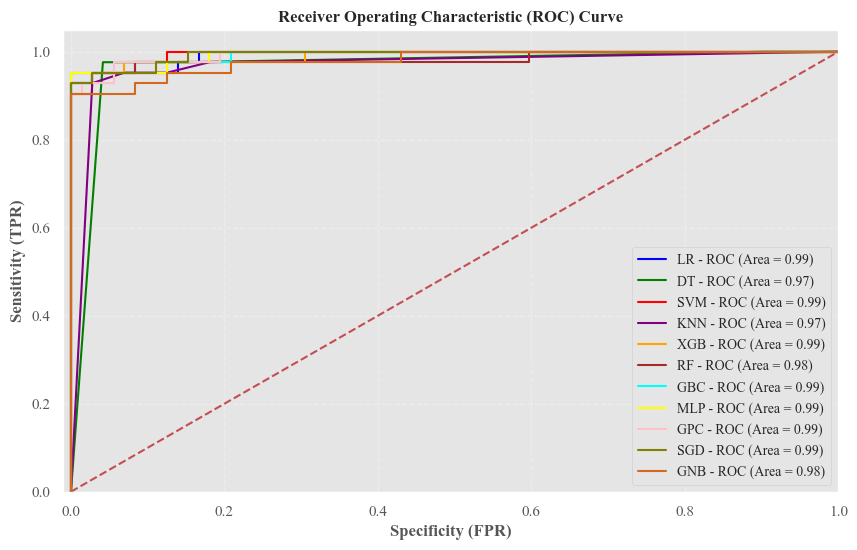

In [92]:
from sklearn import metrics

fig, ax = plt.subplots(figsize = (10, 6))

models = [{'label': 'LR', 'model': logreg, 'color': 'blue'},
          {'label': 'DT', 'model': dt, 'color': 'green'},
          {'label': 'SVM', 'model': svc, 'color': 'red'},
          {'label': 'KNN', 'model': knn, 'color': 'purple'},
          {'label': 'XGB', 'model': xgb, 'color': 'orange'},
          {'label': 'RF', 'model': rf, 'color': 'brown'},
          {'label': 'GBC', 'model': gbc, 'color': 'cyan'},
          {'label': 'MLP', 'model': mlp, 'color': 'yellow'},
          {'label': 'GPC', 'model': gpc, 'color': 'pink'},
          {'label': 'SGD', 'model': sgd, 'color': 'olive'},
          {'label': 'GNB', 'model': gnb, 'color': 'chocolate'}]

for m in models:
    model = m['model']
    model.fit(X_train, y_train)
    y_pred = model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)
    auc = metrics.roc_auc_score(y_test, y_pred)
    ax.plot(fpr, tpr, label = '%s - ROC (Area = %0.2f)' % (m['label'], auc), color = m['color'])

ax.plot([0, 1], [0, 1], 'r--')
ax.set_xlim([-0.01, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Specificity (FPR)', fontweight = 'bold', fontsize = 12)
ax.set_ylabel('Sensitivity (TPR)', fontweight = 'bold', fontsize = 12)
ax.set_title('Receiver Operating Characteristic (ROC) Curve', fontweight = 'bold', fontsize = 12)
ax.grid(True, linestyle = '--', alpha = 0.3)
ax.legend(loc = "lower right", fontsize = 10)

plt.show()